# FracAtlas Segmentation — U-Net++-SE

- Dataset: `FracAtlas/segmentation`.
- Split: dùng đúng `train.csv`, `val.csv`, `test.csv`; **không tự chia lại dữ liệu**.
- Baseline bắt buộc: `resize_256`.
- Option cộng điểm nhẹ, chạy được trên Colab free: `keep_ratio_padding_256` — giữ tỉ lệ ảnh gốc rồi padding về 256x256, tránh méo hình như resize vuông.
- `no_resize_original` vẫn còn trong code nhưng **tắt mặc định** vì batch size 1 + ảnh gốc lớn chạy rất lâu và dễ OOM trên Colab free.
- Metrics: Dice, IoU, Precision, Recall, GT mask area, Pred mask area.
- Output CSV: xuất theo đúng template segmentation, gồm cả các cột truy vết AI và khả năng giải thích.
- Visualization: lưu overlay Input / GT / Probability / Pred / Overlay để đưa vào báo cáo.

In [ ]:
# ============================================================
# 1. CÀI / IMPORT THƯ VIỆN
# ============================================================

import os
import sys
import math
import time
import gc
import json
import random
import shutil
import subprocess
import zipfile
import tarfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance, ImageOps, ImageFile, UnidentifiedImageError
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


def ensure_package(import_name, pip_name=None):
    """Cài package nếu chưa có. Nếu môi trường offline thì chỉ cảnh báo, không crash notebook."""
    import importlib.util
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is not None:
        return True
    try:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        return importlib.util.find_spec(import_name) is not None
    except Exception as e:
        print(f"Không cài được {pip_name}. Sẽ dùng fallback nếu có. Lỗi: {repr(e)}")
        return False

HAS_GDOWN = ensure_package("gdown", "gdown")
HAS_TIMM = ensure_package("timm", "timm")

try:
    import gdown
except Exception:
    gdown = None

try:
    import timm
except Exception:
    timm = None
    HAS_TIMM = False


try:
    from scipy import ndimage
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False
    ndimage = None

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("timm available:", HAS_TIMM)
print("SciPy available:", HAS_SCIPY)

torch: 2.11.0+cu128
CUDA available: True
timm available: True
SciPy available: True


In [ ]:

# ============================================================
# 2. CONFIG CHÍNH - COLAB FREE
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

# ------------------------------------------------------------
# Thông tin nhóm - sửa nếu cần trước khi chạy để CSV/report đúng tên.
# ------------------------------------------------------------
GROUP_NUMBER = "07"
GROUP_NAME = f"Group{GROUP_NUMBER}"
GROUP_ID = f"G{GROUP_NUMBER}"
TASK_ID = f"T{GROUP_NUMBER}"
STUDENT_1 = "Nguyen Thai Thong"
STUDENT_2 = "Tran Ha Khanh Duy"
DATASET_DISPLAY_NAME = "FracAtlas/segmentation"
MODEL_DISPLAY_NAME = "U-Net++-SE"

# ------------------------------------------------------------
# Môi trường chạy.
# ------------------------------------------------------------
IS_COLAB = Path("/content").exists()
IS_KAGGLE = Path("/kaggle/input").exists()
WORK_DIR = Path("/content") if IS_COLAB else (Path("/kaggle/working") if IS_KAGGLE else Path.cwd())
OUTPUT_DIR = WORK_DIR / "fracatlas_unetpp_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Colab: mount Google Drive để đọc dataset.
MOUNT_DRIVE = True
COPY_DATASET_TO_LOCAL = True
FORCE_RECOPY_LOCAL = False
ALLOW_SLOW_DRIVE_SEARCH = False

# Root dataset sau khi giải nén local.
MANUAL_DATA_ROOT = Path("/content/drive/MyDrive/segmentation")

PROJECT_FOLDER_NAME = "TH_TGMT_DTTLoan_Segmentation_Classification_YKhoa"
TRY_DOWNLOAD_FROM_DRIVE = False
FRACATLAS_FILE_ID = "1DeJK1z59TNTuqAwA8jnhPQHO37amdYNn"

# ------------------------------------------------------------
# Các mode chạy.
# ------------------------------------------------------------
INPUT_SIZE = 256
RUN_BASELINE_RESIZE = True
RUN_KEEP_RATIO_PADDING = False
RUN_TRUE_NO_RESIZE = True

RUN_MODES = []
if RUN_BASELINE_RESIZE:
    RUN_MODES.append("resize_256")
if RUN_KEEP_RATIO_PADDING:
    RUN_MODES.append("keep_ratio_padding_256")
if RUN_TRUE_NO_RESIZE:
    RUN_MODES.append("no_resize_original")

# Giữ biến này để các cell cũ/checklist không lỗi.
RUN_NO_RESIZE_DEMO = RUN_TRUE_NO_RESIZE

USE_PRETRAINED_ENCODER = True
TIMM_ENCODER_NAME = "efficientnet_b3"
IN_CHANNELS = 3

DECODER_CHANNELS_RESIZE = [48, 96, 192, 384]
DECODER_CHANNELS_KEEP_RATIO = [48, 96, 192, 384]
DECODER_CHANNELS_NO_RESIZE = [16, 32, 64, 96]
DECODER_CHANNELS = DECODER_CHANNELS_RESIZE

DECODER_NORM = "groupnorm"
DROPOUT_P = 0.07
DECODER_USE_SE = True
USE_DEEP_SUPERVISION_AVERAGE = True
USE_DECODER_CHECKPOINT = True

FREEZE_ENCODER_EPOCHS = 1
FREEZE_ENCODER_NO_RESIZE_ALL_EPOCHS = False

# ------------------------------------------------------------
# Training mặc định cho Colab free.
# ------------------------------------------------------------
EPOCHS_RESIZE = 40
EPOCHS_KEEP_RATIO_PADDING = 8
EPOCHS_NO_RESIZE = 4

BATCH_SIZE_RESIZE = 12
BATCH_SIZE_NO_RESIZE = 1
ACCUM_STEPS_RESIZE = 2
ACCUM_STEPS_NO_RESIZE = 2

# Giới hạn riêng cho no_resize_original để tránh OOM.
NO_RESIZE_MAX_TRAIN_SAMPLES = 192
NO_RESIZE_MAX_VAL_SAMPLES = 128
NO_RESIZE_MAX_TEST_SAMPLES = 160
NO_RESIZE_MAX_SIDE = 352

ENCODER_LR = 3e-5
DECODER_LR = 3.5e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2 if IS_COLAB or IS_KAGGLE else 0
USE_AMP = True
SKIP_OOM_BATCHES = True
NO_RESIZE_CLIP_LOGITS = 20.0
SKIP_NONFINITE_LOSS_BATCHES = True

# Oversampling chỉ trong train.csv; không đụng val/test.
USE_POSITIVE_OVERSAMPLING = True
TARGET_POSITIVE_RATIO = 0.55
TARGET_POSITIVE_RATIO_NO_RESIZE = 0.85

# Loss cho fracture nhỏ.
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.85
TVERSKY_ALPHA = 0.25
TVERSKY_BETA = 0.75
LOSS_BCE_WEIGHT = 0.35
LOSS_TVERSKY_WEIGHT = 0.65

# Threshold chọn trên val.csv, không chọn trên test.
THRESHOLD_CANDIDATES = [0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60]
THRESHOLD_CANDIDATES_NO_RESIZE = [0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25]
MONITOR_THRESHOLDS = [0.08, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]
MONITOR_THRESHOLDS_NO_RESIZE = [0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25]

THRESHOLD_SCORE_DICE_POSITIVE_WEIGHT = 0.70
THRESHOLD_SCORE_NORMAL_EMPTY_WEIGHT = 0.30

# Image-level gate: giảm false positive trên ảnh normal. Giữ grid nhỏ để không tốn thời gian.
USE_IMAGE_LEVEL_GATE = True
USE_IMAGE_LEVEL_GATE_RESIZE = True
USE_IMAGE_LEVEL_GATE_KEEP_RATIO = True
USE_IMAGE_LEVEL_GATE_NO_RESIZE = False
GATE_SOFT_AREA_PROB_THRESHOLD = 0.30
GATE_SEG_THRESHOLD_CANDIDATES = [0.08, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
GATE_MAX_PROB_CANDIDATES = [0.55, 0.65, 0.75]
GATE_MIN_AREA_RATIO_CANDIDATES_RESIZE = [0.0, 0.00010, 0.00025, 0.00050]
GATE_MIN_AREA_RATIO_CANDIDATES_KEEP_RATIO = [0.0, 0.00010, 0.00025, 0.00050]
GATE_MIN_AREA_RATIO_CANDIDATES_NO_RESIZE = [0.0, 0.00010, 0.00050]

GATE_SCORE_DICE_POSITIVE_WEIGHT = 0.70
GATE_SCORE_DICE_ALL_WEIGHT = 0.15
GATE_SCORE_NORMAL_EMPTY_WEIGHT = 0.15

POSTPROCESS_MIN_COMPONENT_AREA_RESIZE = 8
POSTPROCESS_MIN_COMPONENT_AREA_KEEP_RATIO = 8
POSTPROCESS_MIN_COMPONENT_AREA_NO_RESIZE = 4
POSTPROCESS_MIN_TOTAL_AREA_RATIO_RESIZE = 0.0001
POSTPROCESS_MIN_TOTAL_AREA_RATIO_KEEP_RATIO = 0.0001
POSTPROCESS_MIN_TOTAL_AREA_RATIO_NO_RESIZE = 0.00005
POSTPROCESS_MAX_TOTAL_AREA_RATIO_RESIZE = 0.20
POSTPROCESS_MAX_TOTAL_AREA_RATIO_KEEP_RATIO = 0.20
POSTPROCESS_MAX_TOTAL_AREA_RATIO_NO_RESIZE = 0.35

DEMO_N_PER_MODE = 6

print("WORK_DIR:", WORK_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("GROUP:", GROUP_ID, STUDENT_1, "|", STUDENT_2)
print("RUN_MODES:", RUN_MODES)
print("TIMM_ENCODER_NAME:", TIMM_ENCODER_NAME)
print("DECODER resize/keep_ratio/no_resize:", DECODER_CHANNELS_RESIZE, DECODER_CHANNELS_KEEP_RATIO, DECODER_CHANNELS_NO_RESIZE)
print("EPOCHS resize/keep_ratio/no_resize:", EPOCHS_RESIZE, EPOCHS_KEEP_RATIO_PADDING, EPOCHS_NO_RESIZE)
print("BATCH_SIZE_RESIZE / NO_RESIZE:", BATCH_SIZE_RESIZE, BATCH_SIZE_NO_RESIZE)
print("RUN_TRUE_NO_RESIZE:", RUN_TRUE_NO_RESIZE)
print("COPY_DATASET_TO_LOCAL:", COPY_DATASET_TO_LOCAL)

WORK_DIR: /content
OUTPUT_DIR: /content/fracatlas_unetpp_outputs
GROUP: G07 Nguyen Thai Thong | Tran Ha Khanh Duy
RUN_MODES: ['resize_256', 'no_resize_original']
TIMM_ENCODER_NAME: efficientnet_b3
DECODER resize/keep_ratio/no_resize: [48, 96, 192, 384] [48, 96, 192, 384] [16, 32, 64, 96]
EPOCHS resize/keep_ratio/no_resize: 40 8 4
BATCH_SIZE_RESIZE / NO_RESIZE: 12 1
RUN_TRUE_NO_RESIZE: True
COPY_DATASET_TO_LOCAL: True


In [ ]:
# ============================================================
# 3. TẢI DATASET TỪ ZIP
# ============================================================
# Dùng file /content/drive/MyDrive/segmentation.zip.
# Copy zip sang /content rồi giải nén để train từ local disk.

REQUIRED_CSV = ["train.csv", "val.csv", "test.csv"]
REQUIRED_DIRS = ["images", "masks"]

DRIVE_ZIP_PATH = Path("/content/drive/MyDrive/segmentation.zip")
LOCAL_ZIP_PATH = Path("/content/segmentation.zip")
EXTRACT_DIR = Path("/content/segmentation_extracted")

# Bật True khi thay file zip trên Drive.
FORCE_REEXTRACT_ZIP = False

if IS_COLAB and MOUNT_DRIVE:
    try:
        from google.colab import drive
        if not Path("/content/drive/MyDrive").exists():
            drive.mount("/content/drive")
        else:
            print("Google Drive đã mount:", Path("/content/drive/MyDrive"))
    except Exception as e:
        print("Không mount được Google Drive tự động. Nếu đang ở Colab, hãy mount thủ công. Lỗi:", repr(e))


def is_valid_segmentation_root(p):
    """Root hợp lệ của bài segmentation."""
    p = Path(p)
    if not p.exists() or not p.is_dir():
        return False
    if not all((p / name).exists() for name in REQUIRED_CSV):
        return False
    if not all((p / name).exists() for name in REQUIRED_DIRS):
        return False
    try:
        df = pd.read_csv(p / "train.csv", nrows=3)
        return "image_path" in df.columns and "mask_path" in df.columns
    except Exception:
        return False


def find_segmentation_root(base_dir):
    """Tìm root segmentation sau khi unzip."""
    base_dir = Path(base_dir)
    direct_candidates = [
        base_dir,
        base_dir / "segmentation",
        base_dir / "FracAtlas" / "segmentation",
        base_dir / "fracatlas" / "segmentation",
        base_dir / "01_Dataset_Curated" / "FracAtlas" / "segmentation",
        base_dir / "01_Dataset_Curated" / "FracAtlas" / "segmentation_realistic",
    ]
    for p in direct_candidates:
        if is_valid_segmentation_root(p):
            return p

    # Chỉ quét trong thư mục đã giải nén.
    for train_csv in base_dir.rglob("train.csv"):
        p = train_csv.parent
        if is_valid_segmentation_root(p):
            return p
    return None


if not DRIVE_ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Không thấy {DRIVE_ZIP_PATH}. Hãy kiểm tra file segmentation.zip đã nằm đúng trong MyDrive chưa."
    )

# Copy zip từ Drive về local.
need_copy_zip = (
    FORCE_REEXTRACT_ZIP
    or not LOCAL_ZIP_PATH.exists()
    or LOCAL_ZIP_PATH.stat().st_size != DRIVE_ZIP_PATH.stat().st_size
)
if need_copy_zip:
    print("Copy segmentation.zip từ Drive về /content ...")
    if LOCAL_ZIP_PATH.exists():
        LOCAL_ZIP_PATH.unlink()
    shutil.copy2(DRIVE_ZIP_PATH, LOCAL_ZIP_PATH)
else:
    print("Local zip đã tồn tại, bỏ qua copy:", LOCAL_ZIP_PATH)

# Giải nén local zip. Nếu đã giải nén và tìm được dataset hợp lệ thì bỏ qua.
DATA_ROOT = None if FORCE_REEXTRACT_ZIP else find_segmentation_root(EXTRACT_DIR)
if DATA_ROOT is None:
    if EXTRACT_DIR.exists():
        print("Xóa thư mục giải nén cũ:", EXTRACT_DIR)
        shutil.rmtree(EXTRACT_DIR)
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    print("Giải nén segmentation.zip vào /content ...")
    if not zipfile.is_zipfile(LOCAL_ZIP_PATH):
        raise RuntimeError(f"{LOCAL_ZIP_PATH} không phải file zip hợp lệ.")
    with zipfile.ZipFile(LOCAL_ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)

    DATA_ROOT = find_segmentation_root(EXTRACT_DIR)

if DATA_ROOT is None:
    raise FileNotFoundError(
        "Đã giải nén segmentation.zip nhưng không tìm thấy folder segmentation hợp lệ. "
        "Folder hợp lệ cần có train.csv, val.csv, test.csv, images/, masks/, "
        "và train.csv có cột image_path, mask_path."
    )

DATA_ROOT = Path(DATA_ROOT)
TRAIN_CSV = DATA_ROOT / "train.csv"
VAL_CSV = DATA_ROOT / "val.csv"
TEST_CSV = DATA_ROOT / "test.csv"

print("DATA_ROOT dùng để train:", DATA_ROOT)
print("train.csv:", TRAIN_CSV.exists())
print("val.csv:", VAL_CSV.exists())
print("test.csv:", TEST_CSV.exists())
print("images:", (DATA_ROOT / "images").exists())
print("masks:", (DATA_ROOT / "masks").exists())
print("Tổng số file trong DATA_ROOT:", sum(1 for _ in DATA_ROOT.rglob("*")))

display(pd.read_csv(TRAIN_CSV, nrows=3))

Mounted at /content/drive
Copy segmentation.zip từ Drive về /content ...
Giải nén segmentation.zip vào /content ...
DATA_ROOT dùng để train: /content/segmentation_extracted/segmentation
train.csv: True
val.csv: True
test.csv: True
images: True
masks: True
Tổng số file trong DATA_ROOT: 8172


,image_id,image_path,mask_id,mask_path,label_binary,label_3class,dataset,original_width,original_height,mask_area,split,note
0,IMG0003879.jpg,images/IMG0003879.jpg,IMG0003879_mask.png,masks/IMG0003879_mask.png,normal,normal,FracAtlas,373,454,0,train,normal_with_empty_mask
1,IMG0001790.jpg,images/IMG0001790.jpg,IMG0001790_mask.png,masks/IMG0001790_mask.png,normal,normal,FracAtlas,373,454,0,train,normal_with_empty_mask
2,IMG0000450.jpg,images/IMG0000450.jpg,IMG0000450_mask.png,masks/IMG0000450_mask.png,normal,normal,FracAtlas,373,454,0,train,normal_with_empty_mask


In [ ]:
# ============================================================
# 4. ĐỌC CSV, KIỂM TRA mask_path, OVERSAMPLING POSITIVE TRONG TRAIN
# ============================================================

train_df_raw = pd.read_csv(TRAIN_CSV)
if not VAL_CSV.exists():
    raise FileNotFoundError("Thiếu val.csv; không được dùng test.csv để tune threshold/checkpoint vì sẽ gây data leakage.")
val_df_raw = pd.read_csv(VAL_CSV)
test_df_raw = pd.read_csv(TEST_CSV)

for name, df in [("train", train_df_raw), ("val", val_df_raw), ("test", test_df_raw)]:
    for col in ["image_path", "mask_path"]:
        if col not in df.columns:
            raise ValueError(f"{name}.csv thiếu cột {col}")


def readable_image(path):
    try:
        ImageFile.LOAD_TRUNCATED_IMAGES = True
        with Image.open(path) as im:
            im.load()
            _ = im.convert("L")
        return True
    except Exception:
        return False


def ensure_mask_area(df, data_root, name):
    df = df.copy()
    if "mask_area" in df.columns and df["mask_area"].notna().all():
        df["mask_area"] = df["mask_area"].astype(float)
        return df

    print(f"Tính mask_area cho {name}.csv vì CSV chưa có hoặc thiếu mask_area...")
    areas = []
    for p in tqdm(df["mask_path"].astype(str), desc=f"mask_area {name}"):
        mask_path = Path(data_root) / p
        try:
            mask = Image.open(mask_path).convert("L")
            arr = np.array(mask)
            areas.append(float((arr > 0).sum()))
        except Exception:
            areas.append(np.nan)
    df["mask_area"] = areas
    return df


train_df_raw = ensure_mask_area(train_df_raw, DATA_ROOT, "train")
val_df_raw = ensure_mask_area(val_df_raw, DATA_ROOT, "val")
test_df_raw = ensure_mask_area(test_df_raw, DATA_ROOT, "test")


def filter_existing_pairs(df, data_root, name, verify_readable=True):
    """
    Giữ đúng split train/val/test, nhưng loại các dòng có file thiếu/corrupt.
    Dataset có thể có vài ảnh truncated; nếu không lọc thì DataLoader sẽ crash giữa epoch.
    """
    ok_rows = []
    missing = 0
    corrupt = 0

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"check files {name}"):
        img_path = Path(data_root) / str(row["image_path"])
        mask_path = Path(data_root) / str(row["mask_path"])

        if not (img_path.exists() and mask_path.exists()):
            missing += 1
            continue

        if verify_readable and (not readable_image(img_path) or not readable_image(mask_path)):
            corrupt += 1
            continue

        ok_rows.append(row)

    out = pd.DataFrame(ok_rows).reset_index(drop=True)
    print(f"{name}: kept {len(out)}/{len(df)} rows | missing pairs: {missing} | corrupt/truncated pairs: {corrupt}")

    if len(out) == 0:
        raise RuntimeError(f"{name}: không còn sample hợp lệ sau khi lọc file thiếu/corrupt.")

    return out


train_df_raw = filter_existing_pairs(train_df_raw, DATA_ROOT, "train")
val_df_raw = filter_existing_pairs(val_df_raw, DATA_ROOT, "val")
test_df_raw = filter_existing_pairs(test_df_raw, DATA_ROOT, "test")


def describe_split(df, name):
    n_pos = int((df["mask_area"] > 0).sum())
    n_neg = int((df["mask_area"] <= 0).sum())
    print(f"{name}: total={len(df)} | positive fracture={n_pos} | normal/empty={n_neg} | positive_ratio={n_pos/max(len(df),1):.3f}")


describe_split(train_df_raw, "train raw")
describe_split(val_df_raw, "val")
describe_split(test_df_raw, "test")


def make_positive_oversampled_train(df, target_positive_ratio=0.60, seed=42):
    positive_df = df[df["mask_area"] > 0].copy()
    negative_df = df[df["mask_area"] <= 0].copy()

    if len(positive_df) == 0 or len(negative_df) == 0:
        print("Không oversample vì thiếu positive hoặc negative.")
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    n_total = len(df)
    n_pos = int(round(n_total * target_positive_ratio))
    n_neg = n_total - n_pos

    pos_sampled = positive_df.sample(n=n_pos, replace=True, random_state=seed)
    neg_sampled = negative_df.sample(n=n_neg, replace=(n_neg > len(negative_df)), random_state=seed)

    balanced = pd.concat([pos_sampled, neg_sampled], ignore_index=True)
    balanced = balanced.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return balanced


if USE_POSITIVE_OVERSAMPLING:
    train_df = make_positive_oversampled_train(train_df_raw, TARGET_POSITIVE_RATIO, SEED)
else:
    train_df = train_df_raw.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

val_df = val_df_raw.reset_index(drop=True)
test_df = test_df_raw.reset_index(drop=True)

train_balanced_csv = OUTPUT_DIR / "train_used_positive_oversampled.csv"
train_df.to_csv(train_balanced_csv, index=False, encoding="utf-8-sig")
print("Saved train used CSV:", train_balanced_csv)

describe_split(train_df, "train used")

display(train_df.head(3))

check files train:   0%|          | 0/2858 [00:00<?, ?it/s]

train: kept 2858/2858 rows | missing pairs: 0 | corrupt/truncated pairs: 0


check files val:   0%|          | 0/612 [00:00<?, ?it/s]

val: kept 612/612 rows | missing pairs: 0 | corrupt/truncated pairs: 0


check files test:   0%|          | 0/613 [00:00<?, ?it/s]

test: kept 613/613 rows | missing pairs: 0 | corrupt/truncated pairs: 0
train raw: total=2858 | positive fracture=502 | normal/empty=2356 | positive_ratio=0.176
val: total=612 | positive fracture=107 | normal/empty=505 | positive_ratio=0.175
test: total=613 | positive fracture=108 | normal/empty=505 | positive_ratio=0.176
Saved train used CSV: /content/fracatlas_unetpp_outputs/train_used_positive_oversampled.csv
train used: total=2858 | positive fracture=1572 | normal/empty=1286 | positive_ratio=0.550


,image_id,image_path,mask_id,mask_path,label_binary,label_3class,dataset,original_width,original_height,mask_area,split,note
0,IMG0004108.jpg,images/IMG0004108.jpg,IMG0004108_mask.png,masks/IMG0004108_mask.png,normal,normal,FracAtlas,373,454,0.0,train,normal_with_empty_mask
1,IMG0004290.jpg,images/IMG0004290.jpg,IMG0004290_mask.png,masks/IMG0004290_mask.png,normal,normal,FracAtlas,373,454,0.0,train,normal_with_empty_mask
2,IMG0002980.jpg,images/IMG0002980.jpg,IMG0002980_mask.png,masks/IMG0002980_mask.png,fracture,fracture,FracAtlas,373,454,178.0,train,fracture_with_coco_mask


In [ ]:
# ============================================================
# 5. PREPROCESS + DATASET
# ============================================================

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_grayscale_image(path):
    path = Path(path)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    with Image.open(path) as im:
        im.load()
        return im.convert("L")

def resize_pair(img, mask, target_size=256):
    """Resize vuông 256x256 cho baseline."""
    w, h = img.size
    img2 = img.resize((target_size, target_size), Image.BILINEAR)
    mask2 = mask.resize((target_size, target_size), Image.NEAREST)
    meta = {
        "scale": -1.0,
        "scale_x": float(target_size / max(w, 1)),
        "scale_y": float(target_size / max(h, 1)),
        "pad_left": 0,
        "pad_top": 0,
        "resized_width": int(target_size),
        "resized_height": int(target_size),
        "padded_width": int(target_size),
        "padded_height": int(target_size),
        "original_width": int(w),
        "original_height": int(h),
    }
    return img2, mask2, meta


def keep_ratio_padding_pair(img, mask, target_size=256):
    """Giữ tỉ lệ ảnh, resize cạnh dài về target_size rồi padding vuông."""
    w, h = img.size
    scale = float(target_size / max(w, h))
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    img_resized = img.resize((new_w, new_h), Image.BILINEAR)
    mask_resized = mask.resize((new_w, new_h), Image.NEAREST)

    img_canvas = Image.new("L", (target_size, target_size), 0)
    mask_canvas = Image.new("L", (target_size, target_size), 0)
    left = (target_size - new_w) // 2
    top = (target_size - new_h) // 2
    img_canvas.paste(img_resized, (left, top))
    mask_canvas.paste(mask_resized, (left, top))

    meta = {
        "scale": scale,
        "scale_x": scale,
        "scale_y": scale,
        "pad_left": int(left),
        "pad_top": int(top),
        "resized_width": int(new_w),
        "resized_height": int(new_h),
        "padded_width": int(target_size),
        "padded_height": int(target_size),
        "original_width": int(w),
        "original_height": int(h),
    }
    return img_canvas, mask_canvas, meta


def no_resize_pair(img, mask):
    """Giữ tỉ lệ gốc; chỉ cap cạnh dài nếu vượt giới hạn VRAM."""
    w0, h0 = img.size
    scale = 1.0

    max_side = globals().get("NO_RESIZE_MAX_SIDE", None)
    if max_side is not None and max(w0, h0) > int(max_side):
        scale = float(int(max_side) / max(w0, h0))
        new_w = max(1, int(round(w0 * scale)))
        new_h = max(1, int(round(h0 * scale)))
        img = img.resize((new_w, new_h), Image.BILINEAR)
        mask = mask.resize((new_w, new_h), Image.NEAREST)

    w, h = img.size
    meta = {
        "scale": float(scale),
        "scale_x": float(w / max(w0, 1)),
        "scale_y": float(h / max(h0, 1)),
        "pad_left": 0,
        "pad_top": 0,
        "resized_width": int(w),
        "resized_height": int(h),
        "padded_width": int(w),
        "padded_height": int(h),
        "original_width": int(w0),
        "original_height": int(h0),
        "no_resize_max_side": "" if max_side is None else int(max_side),
    }
    return img, mask, meta


def apply_train_augmentation(img, mask):
    # Augment nhẹ, không thay đổi pipeline resize/no_resize bên dưới.
    if random.random() < 0.5:
        img = ImageOps.mirror(img)
        mask = ImageOps.mirror(mask)
    if random.random() < 0.15:
        img = ImageOps.flip(img)
        mask = ImageOps.flip(mask)
    if random.random() < 0.25:
        angle = random.uniform(-7.0, 7.0)
        img = img.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
        mask = mask.rotate(angle, resample=Image.NEAREST, fillcolor=0)
    if random.random() < 0.25:
        img = ImageOps.autocontrast(img)
    if random.random() < 0.40:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.80, 1.30))
    if random.random() < 0.35:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.88, 1.14))
    return img, mask


def sanitize_meta(meta):
    clean = {}
    for k, v in meta.items():
        if v is None:
            clean[k] = ""
        elif isinstance(v, Path):
            clean[k] = str(v)
        elif isinstance(v, np.integer):
            clean[k] = int(v)
        elif isinstance(v, np.floating):
            fv = float(v)
            clean[k] = fv if np.isfinite(fv) else ""
        elif isinstance(v, float):
            clean[k] = v if math.isfinite(v) else ""
        elif isinstance(v, int):
            clean[k] = int(v)
        else:
            clean[k] = v
    return clean


class FracAtlasSegmentationDataset(Dataset):
    def __init__(self, df, data_root, preprocess_mode="resize_256", train=False):
        self.df = df.reset_index(drop=True).copy()
        self.data_root = Path(data_root)
        self.preprocess_mode = preprocess_mode
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.data_root / str(row["image_path"])
        mask_path = self.data_root / str(row["mask_path"])

        # Lấy mask đúng theo CSV.
        img = load_grayscale_image(img_path)
        mask = load_grayscale_image(mask_path)


        if self.train:
            img, mask = apply_train_augmentation(img, mask)

        if self.preprocess_mode == "resize_256":
            img, mask, meta = resize_pair(img, mask, INPUT_SIZE)
        elif self.preprocess_mode == "keep_ratio_padding_256":
            img, mask, meta = keep_ratio_padding_pair(img, mask, INPUT_SIZE)
        elif self.preprocess_mode == "no_resize_original":
            img, mask, meta = no_resize_pair(img, mask)
        else:
            raise ValueError(f"Unknown preprocess_mode: {self.preprocess_mode}")

        img_np = np.array(img, dtype=np.float32) / 255.0
        mask_np = (np.array(mask, dtype=np.uint8) > 0).astype(np.float32)

        # Grayscale được lặp thành 3 channel cho encoder pretrained.
        img_np = np.stack([img_np, img_np, img_np], axis=-1)
        img_np = (img_np - IMAGENET_MEAN) / IMAGENET_STD
        img_np = np.transpose(img_np, (2, 0, 1))

        x = torch.from_numpy(img_np).float()
        y = torch.from_numpy(mask_np[None, :, :]).float()

        image_id = row["image_id"] if "image_id" in row.index else Path(str(row["image_path"])).name
        meta.update({
            "row_index": int(idx),
            "image_id": str(image_id),
            "image_path": str(row["image_path"]),
            "mask_path": str(row["mask_path"]),
            "preprocess_mode": self.preprocess_mode,
            "gt_mask_area_original": float(row["mask_area"]) if "mask_area" in row.index else float(mask_np.sum()),
        })
        meta = sanitize_meta(meta)
        return x, y, meta


# Quick check 1 sample mỗi mode
for mode in RUN_MODES:
    ds = FracAtlasSegmentationDataset(train_df.head(2), DATA_ROOT, preprocess_mode=mode, train=False)
    x, y, meta = ds[0]
    print(mode, "x", tuple(x.shape), "y", tuple(y.shape), "meta size", meta["original_width"], meta["original_height"])

resize_256 x (3, 256, 256) y (1, 256, 256) meta size 373 454
no_resize_original x (3, 352, 289) y (1, 352, 289) meta size 373 454


In [ ]:

# ============================================================
# 6. MODEL: pretrained encoder + U-Net++ decoder
# ============================================================

from torch.utils.checkpoint import checkpoint


def make_norm(num_channels):
    """Norm cho batch nhỏ."""
    if DECODER_NORM == "batchnorm":
        return nn.BatchNorm2d(num_channels)
    groups = min(8, num_channels)
    while groups > 1 and num_channels % groups != 0:
        groups -= 1
    return nn.GroupNorm(groups, num_channels)


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(4, channels // reduction)
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, kernel_size=1),
            nn.SiLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.gate(x)


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.0, use_se=None):
        super().__init__()
        if use_se is None:
            use_se = bool(globals().get("DECODER_USE_SE", False))
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            make_norm(out_ch),
            nn.SiLU(inplace=True),
        ]
        if dropout_p and dropout_p > 0:
            layers.append(nn.Dropout2d(dropout_p))
        layers += [
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            make_norm(out_ch),
            nn.SiLU(inplace=True),
        ]
        if use_se:
            layers.append(SEBlock(out_ch))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


def up_to(x, ref):
    """Upsample theo spatial size của feature tham chiếu."""
    return F.interpolate(x, size=ref.shape[-2:], mode="bilinear", align_corners=False)


def run_block(block, x):
    """Checkpoint decoder block khi cần giảm VRAM."""
    if USE_DECODER_CHECKPOINT and torch.is_grad_enabled() and x.requires_grad:
        return checkpoint(block, x, use_reentrant=False)
    return block(x)


class FlexibleUNetPlusPlus(nn.Module):
    """U-Net++ decoder với timm encoder pretrained."""
    def __init__(
        self,
        encoder_name="efficientnet_b3",
        pretrained=True,
        in_channels=3,
        out_channels=1,
        decoder_channels=(64, 128, 256, 512),
        dropout_p=0.05,
    ):
        super().__init__()
        if timm is None:
            raise RuntimeError("timm chưa import được. Hãy bật Internet trên Kaggle hoặc cài package timm.")

        self.encoder_name = encoder_name
        self.pretrained = pretrained
        self.encoder = timm.create_model(
            encoder_name,
            pretrained=pretrained,
            features_only=True,
            in_chans=in_channels,
            out_indices=(0, 1, 2, 3, 4),
        )
        enc_ch = list(self.encoder.feature_info.channels())
        if len(enc_ch) < 5:
            raise RuntimeError(f"Encoder {encoder_name} chỉ trả {len(enc_ch)} feature maps, cần 5.")

        ch0, ch1, ch2, ch3, ch4 = enc_ch[:5]
        d0, d1, d2, d3 = decoder_channels

        self.enc_channels = enc_ch[:5]
        self.dec_channels = list(decoder_channels)

        self.conv0_1 = ConvBNAct(ch0 + ch1, d0, dropout_p)
        self.conv1_1 = ConvBNAct(ch1 + ch2, d1, dropout_p)
        self.conv2_1 = ConvBNAct(ch2 + ch3, d2, dropout_p)
        self.conv3_1 = ConvBNAct(ch3 + ch4, d3, dropout_p)

        self.conv0_2 = ConvBNAct(ch0 + d0 + d1, d0, dropout_p)
        self.conv1_2 = ConvBNAct(ch1 + d1 + d2, d1, dropout_p)
        self.conv2_2 = ConvBNAct(ch2 + d2 + d3, d2, dropout_p)

        self.conv0_3 = ConvBNAct(ch0 + d0 + d0 + d1, d0, dropout_p)
        self.conv1_3 = ConvBNAct(ch1 + d1 + d1 + d2, d1, dropout_p)

        self.conv0_4 = ConvBNAct(ch0 + d0 + d0 + d0 + d1, d0, dropout_p)

        self.use_deep_supervision_average = bool(globals().get("USE_DEEP_SUPERVISION_AVERAGE", False))
        self.final_1 = nn.Conv2d(d0, out_channels, kernel_size=1)
        self.final_2 = nn.Conv2d(d0, out_channels, kernel_size=1)
        self.final_3 = nn.Conv2d(d0, out_channels, kernel_size=1)
        self.final_4 = nn.Conv2d(d0, out_channels, kernel_size=1)
        self.final = self.final_4

    def forward(self, x):
        input_size = x.shape[-2:]
        x0_0, x1_0, x2_0, x3_0, x4_0 = self.encoder(x)

        x0_1 = run_block(self.conv0_1, torch.cat([x0_0, up_to(x1_0, x0_0)], dim=1))
        x1_1 = run_block(self.conv1_1, torch.cat([x1_0, up_to(x2_0, x1_0)], dim=1))
        x2_1 = run_block(self.conv2_1, torch.cat([x2_0, up_to(x3_0, x2_0)], dim=1))
        x3_1 = run_block(self.conv3_1, torch.cat([x3_0, up_to(x4_0, x3_0)], dim=1))

        x0_2 = run_block(self.conv0_2, torch.cat([x0_0, x0_1, up_to(x1_1, x0_0)], dim=1))
        x1_2 = run_block(self.conv1_2, torch.cat([x1_0, x1_1, up_to(x2_1, x1_0)], dim=1))
        x2_2 = run_block(self.conv2_2, torch.cat([x2_0, x2_1, up_to(x3_1, x2_0)], dim=1))

        x0_3 = run_block(self.conv0_3, torch.cat([x0_0, x0_1, x0_2, up_to(x1_2, x0_0)], dim=1))
        x1_3 = run_block(self.conv1_3, torch.cat([x1_0, x1_1, x1_2, up_to(x2_2, x1_0)], dim=1))

        x0_4 = run_block(self.conv0_4, torch.cat([x0_0, x0_1, x0_2, x0_3, up_to(x1_3, x0_0)], dim=1))

        if self.use_deep_supervision_average:
            l1 = F.interpolate(self.final_1(x0_1), size=input_size, mode="bilinear", align_corners=False)
            l2 = F.interpolate(self.final_2(x0_2), size=input_size, mode="bilinear", align_corners=False)
            l3 = F.interpolate(self.final_3(x0_3), size=input_size, mode="bilinear", align_corners=False)
            l4 = F.interpolate(self.final_4(x0_4), size=input_size, mode="bilinear", align_corners=False)
            return 0.10 * l1 + 0.20 * l2 + 0.30 * l3 + 0.40 * l4

        logits = self.final_4(x0_4)
        return F.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)


def get_decoder_channels_for_mode(preprocess_mode):
    if preprocess_mode == "no_resize_original":
        return DECODER_CHANNELS_NO_RESIZE
    if preprocess_mode == "keep_ratio_padding_256":
        return DECODER_CHANNELS_KEEP_RATIO
    return DECODER_CHANNELS_RESIZE


def build_model(preprocess_mode=None):
    """Tạo model theo từng preprocess mode."""
    if timm is None:
        raise RuntimeError("Không có timm nên không tạo được pretrained encoder. Hãy bật Internet/cài timm trong Kaggle.")

    decoder_channels = get_decoder_channels_for_mode(preprocess_mode)

    try:
        model = FlexibleUNetPlusPlus(
            encoder_name=TIMM_ENCODER_NAME,
            pretrained=USE_PRETRAINED_ENCODER,
            in_channels=IN_CHANNELS,
            out_channels=1,
            decoder_channels=decoder_channels,
            dropout_p=DROPOUT_P,
        )
        weight_name = "imagenet" if USE_PRETRAINED_ENCODER else "scratch"
        ch_tag = "x".join(map(str, decoder_channels))
        model_name = f"Flexible_UNetPlusPlus_{TIMM_ENCODER_NAME}_{weight_name}_dec{ch_tag}_{DECODER_NORM}"
        print("Model:", model_name)
        print("Preprocess mode:", preprocess_mode)
        print("Encoder channels:", model.enc_channels)
        print("Decoder channels:", model.dec_channels)
        return model, model_name
    except Exception as e:
        if USE_PRETRAINED_ENCODER:
            print("Không tạo được pretrained encoder, thử weights=None. Lỗi:", repr(e))
            model = FlexibleUNetPlusPlus(
                encoder_name=TIMM_ENCODER_NAME,
                pretrained=False,
                in_channels=IN_CHANNELS,
                out_channels=1,
                decoder_channels=decoder_channels,
                dropout_p=DROPOUT_P,
            )
            ch_tag = "x".join(map(str, decoder_channels))
            model_name = f"Flexible_UNetPlusPlus_{TIMM_ENCODER_NAME}_scratch_dec{ch_tag}_{DECODER_NORM}"
            print("Model:", model_name)
            print("Preprocess mode:", preprocess_mode)
            print("Encoder channels:", model.enc_channels)
            print("Decoder channels:", model.dec_channels)
            return model, model_name
        raise


def set_encoder_trainable(model, trainable=True):
    if hasattr(model, "encoder"):
        for p in model.encoder.parameters():
            p.requires_grad = bool(trainable)
        # Freeze thì để encoder ở eval.
        if trainable:
            model.encoder.train()
        else:
            model.encoder.eval()
    model.encoder_frozen_runtime = not bool(trainable)


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Smoke test cho các mode sẽ chạy.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for _mode in RUN_MODES:
    _shape = (1, IN_CHANNELS, 373, 454) if _mode == "no_resize_original" else (1, IN_CHANNELS, INPUT_SIZE, INPUT_SIZE)
    _test_model, _test_name = build_model(_mode)
    _test_model = _test_model.to(device)
    _test_model.eval()
    with torch.no_grad():
        a = torch.randn(*_shape, device=device)
        b = _test_model(a)
        print(f"Smoke {_mode} {_shape[-2:]} ->", tuple(b.shape), "|", _test_name)
    del _test_model, a, b
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Model: Flexible_UNetPlusPlus_efficientnet_b3_imagenet_dec48x96x192x384_groupnorm
Preprocess mode: resize_256
Encoder channels: [24, 32, 48, 136, 384]
Decoder channels: [48, 96, 192, 384]
Smoke resize_256 (256, 256) -> (1, 1, 256, 256) | Flexible_UNetPlusPlus_efficientnet_b3_imagenet_dec48x96x192x384_groupnorm


Model: Flexible_UNetPlusPlus_efficientnet_b3_imagenet_dec16x32x64x96_groupnorm
Preprocess mode: no_resize_original
Encoder channels: [24, 32, 48, 136, 384]
Decoder channels: [16, 32, 64, 96]
Smoke no_resize_original (373, 454) -> (1, 1, 373, 454) | Flexible_UNetPlusPlus_efficientnet_b3_imagenet_dec16x32x64x96_groupnorm


In [ ]:
# ============================================================
# 7. LOSS, METRICS, POSTPROCESS
# ============================================================

def resize_logits_to_target(logits, target):
    if logits.shape[-2:] != target.shape[-2:]:
        logits = F.interpolate(logits, size=target.shape[-2:], mode="bilinear", align_corners=False)
    return logits


def focal_bce_with_logits(logits, targets, alpha=0.75, gamma=2.0):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    prob = torch.sigmoid(logits)
    pt = torch.where(targets == 1, prob, 1 - prob)
    alpha_t = torch.where(targets == 1, torch.tensor(alpha, device=targets.device), torch.tensor(1 - alpha, device=targets.device))
    loss = alpha_t * (1 - pt).pow(gamma) * bce
    return loss.mean()


def tversky_loss(logits, targets, alpha=0.30, beta=0.70, smooth=1e-6):
    prob = torch.sigmoid(logits)
    dims = (1, 2, 3)
    tp = (prob * targets).sum(dims)
    fp = (prob * (1 - targets)).sum(dims)
    fn = ((1 - prob) * targets).sum(dims)
    tversky = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    return 1 - tversky.mean()


def segmentation_loss(logits, targets):
    logits = resize_logits_to_target(logits, targets)
    loss_bce = focal_bce_with_logits(logits, targets, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
    loss_tv = tversky_loss(logits, targets, alpha=TVERSKY_ALPHA, beta=TVERSKY_BETA)
    return LOSS_BCE_WEIGHT * loss_bce + LOSS_TVERSKY_WEIGHT * loss_tv


def postprocess_binary_mask(binary_mask, min_component_area=0):
    binary_mask = binary_mask.astype(np.uint8)
    if min_component_area <= 0 or binary_mask.sum() == 0:
        return binary_mask
    if not HAS_SCIPY:
        return binary_mask

    labeled, n = ndimage.label(binary_mask)
    if n == 0:
        return binary_mask

    out = np.zeros_like(binary_mask, dtype=np.uint8)
    for lab in range(1, n + 1):
        comp = labeled == lab
        if int(comp.sum()) >= min_component_area:
            out[comp] = 1
    return out


def compute_segmentation_metrics(pred_mask, gt_mask, eps=1e-7):
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)

    pred_area = float(pred.sum())
    gt_area = float(gt.sum())

    # Normal đúng.
    if gt_area == 0 and pred_area == 0:
        return {
            "dice": 1.0,
            "iou": 1.0,
            "precision": 1.0,
            "recall": 1.0,
            "gt_mask_area": gt_area,
            "pred_mask_area": pred_area,
        }

    # Normal false positive.
    if gt_area == 0 and pred_area > 0:
        return {
            "dice": 0.0,
            "iou": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "gt_mask_area": gt_area,
            "pred_mask_area": pred_area,
        }

    # Fracture false negative.
    if gt_area > 0 and pred_area == 0:
        return {
            "dice": 0.0,
            "iou": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "gt_mask_area": gt_area,
            "pred_mask_area": pred_area,
        }

    inter = float(np.logical_and(pred, gt).sum())
    union = float(np.logical_or(pred, gt).sum())

    dice = (2 * inter + eps) / (pred_area + gt_area + eps)
    iou = (inter + eps) / (union + eps)
    precision = (inter + eps) / (pred_area + eps)
    recall = (inter + eps) / (gt_area + eps)

    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "gt_mask_area": gt_area,
        "pred_mask_area": pred_area,
    }


def get_postprocess_area(preprocess_mode):
    if preprocess_mode == "no_resize_original":
        return POSTPROCESS_MIN_COMPONENT_AREA_NO_RESIZE
    if preprocess_mode == "keep_ratio_padding_256":
        return POSTPROCESS_MIN_COMPONENT_AREA_KEEP_RATIO
    return POSTPROCESS_MIN_COMPONENT_AREA_RESIZE


def get_postprocess_total_area_bounds(preprocess_mode):
    if preprocess_mode == "no_resize_original":
        return (
            POSTPROCESS_MIN_TOTAL_AREA_RATIO_NO_RESIZE,
            POSTPROCESS_MAX_TOTAL_AREA_RATIO_NO_RESIZE,
        )
    if preprocess_mode == "keep_ratio_padding_256":
        return (
            POSTPROCESS_MIN_TOTAL_AREA_RATIO_KEEP_RATIO,
            POSTPROCESS_MAX_TOTAL_AREA_RATIO_KEEP_RATIO,
        )
    return (
        POSTPROCESS_MIN_TOTAL_AREA_RATIO_RESIZE,
        POSTPROCESS_MAX_TOTAL_AREA_RATIO_RESIZE,
    )


def postprocess_prediction_mask(binary_mask, preprocess_mode):
    """Lọc component nhỏ và các mask có diện tích bất thường."""
    out = postprocess_binary_mask(
        binary_mask,
        min_component_area=get_postprocess_area(preprocess_mode),
    )
    area = float(out.sum())
    if area <= 0:
        return out

    min_ratio, max_ratio = get_postprocess_total_area_bounds(preprocess_mode)
    total_pixels = float(out.size)
    ratio = area / max(total_pixels, 1.0)

    if min_ratio is not None and ratio < float(min_ratio):
        return np.zeros_like(out, dtype=np.uint8)
    if max_ratio is not None and ratio > float(max_ratio):
        return np.zeros_like(out, dtype=np.uint8)
    return out



def get_gate_min_area_ratio_candidates(preprocess_mode):
    if preprocess_mode == "no_resize_original":
        return GATE_MIN_AREA_RATIO_CANDIDATES_NO_RESIZE
    if preprocess_mode == "keep_ratio_padding_256":
        return GATE_MIN_AREA_RATIO_CANDIDATES_KEEP_RATIO
    return GATE_MIN_AREA_RATIO_CANDIDATES_RESIZE


def get_threshold_candidates(preprocess_mode):
    """Danh sách threshold theo mode."""
    if preprocess_mode == "no_resize_original":
        return THRESHOLD_CANDIDATES_NO_RESIZE
    return THRESHOLD_CANDIDATES


def should_use_image_level_gate(preprocess_mode):
    """Bật/tắt gate theo mode."""
    if not USE_IMAGE_LEVEL_GATE:
        return False
    if preprocess_mode == "no_resize_original":
        return bool(USE_IMAGE_LEVEL_GATE_NO_RESIZE)
    if preprocess_mode == "keep_ratio_padding_256":
        return bool(USE_IMAGE_LEVEL_GATE_KEEP_RATIO)
    return bool(USE_IMAGE_LEVEL_GATE_RESIZE)


def parse_bool_like(x):
    if isinstance(x, str):
        return x.strip().lower() in {"1", "true", "yes", "y"}
    if pd.isna(x):
        return False
    return bool(x)


def build_gate_config(
    seg_threshold=0.5,
    gate_max_prob_threshold=None,
    gate_min_soft_area_ratio=None,
    gate_soft_area_prob_threshold=None,
    enabled=True,
):
    return {
        "enabled": bool(enabled),
        "seg_threshold": float(seg_threshold),
        "gate_max_prob_threshold": float(gate_max_prob_threshold) if gate_max_prob_threshold is not None else np.nan,
        "gate_min_soft_area_ratio": float(gate_min_soft_area_ratio) if gate_min_soft_area_ratio is not None else np.nan,
        "gate_soft_area_prob_threshold": float(gate_soft_area_prob_threshold) if gate_soft_area_prob_threshold is not None else float(GATE_SOFT_AREA_PROB_THRESHOLD),
    }


def gate_config_from_summary_row(row):
    """Tạo lại gate_config từ summary/result row."""
    threshold = float(row["threshold"]) if "threshold" in row and not pd.isna(row["threshold"]) else 0.5
    enabled = parse_bool_like(row.get("gate_enabled", False)) if hasattr(row, "get") else False
    if not enabled:
        return build_gate_config(seg_threshold=threshold, enabled=False)

    return build_gate_config(
        seg_threshold=float(row.get("seg_threshold", threshold)),
        gate_max_prob_threshold=float(row.get("gate_max_prob_threshold", np.nan)),
        gate_min_soft_area_ratio=float(row.get("gate_min_soft_area_ratio", np.nan)),
        gate_soft_area_prob_threshold=float(row.get("gate_soft_area_prob_threshold", GATE_SOFT_AREA_PROB_THRESHOLD)),
        enabled=True,
    )


def probability_gate_features(prob_map, gate_config=None):
    """Tính feature image-level cho gate."""
    prob = np.asarray(prob_map, dtype=np.float32)
    max_prob = float(prob.max()) if prob.size else 0.0

    if gate_config is None:
        gate_config = build_gate_config(enabled=False)

    enabled = bool(gate_config.get("enabled", False))
    soft_thr = float(gate_config.get("gate_soft_area_prob_threshold", GATE_SOFT_AREA_PROB_THRESHOLD))
    soft_area = float((prob >= soft_thr).sum())
    soft_area_ratio = float(soft_area / max(float(prob.size), 1.0))

    max_thr = gate_config.get("gate_max_prob_threshold", np.nan)
    min_area_ratio = gate_config.get("gate_min_soft_area_ratio", np.nan)

    if enabled:
        gate_pass = (
            np.isfinite(max_thr)
            and np.isfinite(min_area_ratio)
            and max_prob >= float(max_thr)
            and soft_area_ratio >= float(min_area_ratio)
        )
    else:
        gate_pass = True

    return {
        "gate_enabled": bool(enabled),
        "gate_max_prob_threshold": float(max_thr) if np.isfinite(max_thr) else np.nan,
        "gate_min_soft_area_ratio": float(min_area_ratio) if np.isfinite(min_area_ratio) else np.nan,
        "gate_soft_area_prob_threshold": float(soft_thr),
        "gate_max_prob": max_prob,
        "gate_soft_area": soft_area,
        "gate_soft_area_ratio": soft_area_ratio,
        "gate_pass": bool(gate_pass),
    }


def make_prediction_from_prob(prob_map, preprocess_mode, seg_threshold=0.5, gate_config=None):
    """Tạo binary mask từ probability map."""
    seg_threshold = float(seg_threshold)
    pred_bin = (np.asarray(prob_map) >= seg_threshold).astype(np.uint8)
    pred_bin = postprocess_prediction_mask(pred_bin, preprocess_mode)

    gate_info = probability_gate_features(prob_map, gate_config)
    pred_area_before_gate = float(pred_bin.sum())

    if gate_info["gate_enabled"] and not gate_info["gate_pass"]:
        pred_bin = np.zeros_like(pred_bin, dtype=np.uint8)

    gate_info["pred_mask_area_before_gate"] = pred_area_before_gate
    return pred_bin, gate_info

def normalize_preprocess_mode_name(preprocess_mode):
    if preprocess_mode == "resize_256":
        return "resize"
    if preprocess_mode == "keep_ratio_padding_256":
        return "keep_ratio_padding"
    if preprocess_mode == "no_resize_original":
        return "no_resize"
    return preprocess_mode


def is_bonus_preprocess_mode(preprocess_mode):
    # Hai mode này được tính là option.
    return preprocess_mode in {"keep_ratio_padding_256", "no_resize_original"}

In [ ]:

# ============================================================
# 8. TRAIN / EVALUATE
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("GPU chưa bật. Trên Colab vào Runtime -> Change runtime type -> GPU rồi chạy lại; train segmentation trên CPU sẽ rất chậm.")


def loader_kwargs(batch_size, shuffle):
    kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": torch.cuda.is_available(),
    }
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 2
    return kwargs


def _sample_fixed(df, n, label):
    """Sample cố định để chạy ổn định giữa các lần."""
    if n is None or len(df) <= int(n):
        return df.reset_index(drop=True)
    sampled = df.sample(n=int(n), random_state=SEED, replace=False).reset_index(drop=True)
    print(f"{label} subset: {len(sampled)}/{len(df)} rows")
    return sampled


TRAIN_DF_BY_MODE = {}
VAL_DF_BY_MODE = {}
TEST_DF_BY_MODE = {}


def make_loaders(preprocess_mode):
    train_df_mode = train_df
    val_df_mode = val_df
    test_df_mode = test_df

    if preprocess_mode == "no_resize_original":
        # no_resize dùng subset nhỏ hơn và train set positive-heavy hơn.
        if USE_POSITIVE_OVERSAMPLING:
            train_df_mode = make_positive_oversampled_train(
                train_df_raw,
                TARGET_POSITIVE_RATIO_NO_RESIZE,
                SEED + 17,
            )
        # Subset để không vượt giới hạn Colab free.
        train_df_mode = _sample_fixed(train_df_mode, NO_RESIZE_MAX_TRAIN_SAMPLES, "no_resize_original train")
        val_df_mode = _sample_fixed(val_df_mode, NO_RESIZE_MAX_VAL_SAMPLES, "no_resize_original val")
        test_df_mode = _sample_fixed(test_df_mode, NO_RESIZE_MAX_TEST_SAMPLES, "no_resize_original test")
        describe_split(train_df_mode, "no_resize train used")
        describe_split(val_df_mode, "no_resize val used")
        describe_split(test_df_mode, "no_resize test used")

    train_df_mode = train_df_mode.reset_index(drop=True)
    val_df_mode = val_df_mode.reset_index(drop=True)
    test_df_mode = test_df_mode.reset_index(drop=True)

    TRAIN_DF_BY_MODE[preprocess_mode] = train_df_mode.copy()
    VAL_DF_BY_MODE[preprocess_mode] = val_df_mode.copy()
    TEST_DF_BY_MODE[preprocess_mode] = test_df_mode.copy()

    train_ds = FracAtlasSegmentationDataset(train_df_mode, DATA_ROOT, preprocess_mode=preprocess_mode, train=True)
    val_ds = FracAtlasSegmentationDataset(val_df_mode, DATA_ROOT, preprocess_mode=preprocess_mode, train=False)
    test_ds = FracAtlasSegmentationDataset(test_df_mode, DATA_ROOT, preprocess_mode=preprocess_mode, train=False)

    batch_size = BATCH_SIZE_NO_RESIZE if preprocess_mode == "no_resize_original" else BATCH_SIZE_RESIZE
    train_loader = DataLoader(train_ds, **loader_kwargs(batch_size, True))
    val_loader = DataLoader(val_ds, **loader_kwargs(batch_size, False))
    test_loader = DataLoader(test_ds, **loader_kwargs(batch_size, False))
    return train_loader, val_loader, test_loader


def get_meta_value(meta, key, i):
    v = meta.get(key, "")
    if torch.is_tensor(v):
        return v[i].item()
    if isinstance(v, (list, tuple)):
        return v[i]
    return v


def make_optimizer(model, no_resize_frozen_encoder=False):
    encoder_params = []
    decoder_params = []
    for name, p in model.named_parameters():
        if no_resize_frozen_encoder and not p.requires_grad:
            continue
        if name.startswith("encoder."):
            encoder_params.append(p)
        else:
            decoder_params.append(p)

    param_groups = []
    if encoder_params:
        param_groups.append({"params": encoder_params, "lr": ENCODER_LR, "name": "encoder"})
    if decoder_params:
        param_groups.append({"params": decoder_params, "lr": DECODER_LR, "name": "decoder"})
    return torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)


def train_one_epoch(model, loader, optimizer, scaler, accumulation_steps=1):
    model.train()
    if getattr(model, "encoder_frozen_runtime", False) and hasattr(model, "encoder"):
        model.encoder.eval()

    total_loss = 0.0
    total_seen = 0
    skipped = 0

    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(loader, desc="train", leave=False)
    for step, (x, y, meta) in enumerate(pbar, start=1):
        try:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
                logits = model(x)
                logits = resize_logits_to_target(logits, y)
                if "NO_RESIZE_CLIP_LOGITS" in globals() and NO_RESIZE_CLIP_LOGITS is not None:
                    logits = torch.clamp(logits, min=-float(NO_RESIZE_CLIP_LOGITS), max=float(NO_RESIZE_CLIP_LOGITS))
                loss = segmentation_loss(logits, y)
                loss_for_backward = loss / accumulation_steps

            if SKIP_NONFINITE_LOSS_BATCHES and not torch.isfinite(loss.detach()):
                skipped += 1
                optimizer.zero_grad(set_to_none=True)
                print("Skip non-finite loss batch. total skipped:", skipped)
                continue

            scaler.scale(loss_for_backward).backward()

            if step % accumulation_steps == 0 or step == len(loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            bs = x.size(0)
            total_loss += float(loss.detach().cpu()) * bs
            total_seen += bs
            pbar.set_postfix(loss=total_loss / max(total_seen, 1))

        except RuntimeError as e:
            if SKIP_OOM_BATCHES and "out of memory" in str(e).lower():
                skipped += 1
                optimizer.zero_grad(set_to_none=True)
                try:
                    del x, y, logits, loss, loss_for_backward
                except Exception:
                    pass
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                print("Skip OOM batch. total skipped:", skipped)
                continue
            raise

    return total_loss / max(total_seen, 1), skipped


@torch.no_grad()
def compute_val_loss_and_monitor(model, loader, preprocess_mode):
    """Tính val loss và score chọn checkpoint."""
    model.eval()
    total_loss = 0.0
    total_seen = 0
    min_area = get_postprocess_area(preprocess_mode)
    monitor_thresholds = MONITOR_THRESHOLDS_NO_RESIZE if preprocess_mode == "no_resize_original" else MONITOR_THRESHOLDS

    dice_pos_by_thr = {float(thr): [] for thr in monitor_thresholds}
    dice_all_by_thr = {float(thr): [] for thr in monitor_thresholds}
    normal_empty_by_thr = {float(thr): [] for thr in monitor_thresholds}

    for x, y, meta in tqdm(loader, desc="val_loss+dice", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
            logits = model(x)
            logits = resize_logits_to_target(logits, y)
            if "NO_RESIZE_CLIP_LOGITS" in globals() and NO_RESIZE_CLIP_LOGITS is not None:
                logits = torch.clamp(logits, min=-float(NO_RESIZE_CLIP_LOGITS), max=float(NO_RESIZE_CLIP_LOGITS))
            loss = segmentation_loss(logits, y)
            prob = torch.sigmoid(logits)

        bs = x.size(0)
        if torch.isfinite(loss.detach()):
            total_loss += float(loss.detach().cpu()) * bs
            total_seen += bs

        prob = torch.nan_to_num(prob, nan=0.0, posinf=1.0, neginf=0.0)
        prob_np = prob.detach().cpu().numpy()
        gt_np = y.detach().cpu().numpy()
        for i in range(prob_np.shape[0]):
            gt_bin = (gt_np[i, 0] > 0.5).astype(np.uint8)
            gt_area = float(gt_bin.sum())
            for thr in monitor_thresholds:
                thr = float(thr)
                pred_bin = (prob_np[i, 0] >= thr).astype(np.uint8)
                pred_bin = postprocess_prediction_mask(pred_bin, preprocess_mode)
                m = compute_segmentation_metrics(pred_bin, gt_bin)
                dice_all_by_thr[thr].append(m["dice"])
                if gt_area > 0:
                    dice_pos_by_thr[thr].append(m["dice"])
                else:
                    normal_empty_by_thr[thr].append(1.0 if float(pred_bin.sum()) == 0.0 else 0.0)

    val_loss = total_loss / max(total_seen, 1)
    rows = []
    for thr in monitor_thresholds:
        thr = float(thr)
        pos_values = dice_pos_by_thr[thr]
        all_values = dice_all_by_thr[thr]
        normal_empty_values = normal_empty_by_thr[thr]
        val_dice_positive = float(np.mean(pos_values)) if len(pos_values) else np.nan
        val_dice_all = float(np.mean(all_values)) if len(all_values) else np.nan
        val_normal_empty_pred_rate = float(np.mean(normal_empty_values)) if len(normal_empty_values) else np.nan

        if np.isfinite(val_dice_positive) and np.isfinite(val_normal_empty_pred_rate):
            val_threshold_score = (
                THRESHOLD_SCORE_DICE_POSITIVE_WEIGHT * val_dice_positive
                + THRESHOLD_SCORE_NORMAL_EMPTY_WEIGHT * val_normal_empty_pred_rate
            )
        elif np.isfinite(val_dice_positive):
            val_threshold_score = val_dice_positive
        else:
            val_threshold_score = val_dice_all

        rows.append({
            "threshold": thr,
            "val_dice_positive": val_dice_positive,
            "val_dice_all": val_dice_all,
            "val_normal_empty_pred_rate": val_normal_empty_pred_rate,
            "val_normal_false_positive_rate": 1.0 - val_normal_empty_pred_rate if np.isfinite(val_normal_empty_pred_rate) else np.nan,
            "val_threshold_score": float(val_threshold_score) if np.isfinite(val_threshold_score) else np.nan,
        })
    monitor_df = pd.DataFrame(rows)
    sort_col = "val_threshold_score" if monitor_df["val_threshold_score"].notna().any() else "val_dice_all"
    best_row = monitor_df.sort_values(sort_col, ascending=False).iloc[0]
    return val_loss, float(best_row[sort_col]), float(best_row["threshold"]), monitor_df

@torch.no_grad()
def collect_prediction_cache(model, loader, preprocess_mode, desc="prob_cache"):
    """Cache probability map để sweep threshold/gate nhanh hơn."""
    model.eval()
    cache = []

    for x, y, meta in tqdm(loader, desc=desc, leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
            logits = model(x)
            logits = resize_logits_to_target(logits, y)
            if "NO_RESIZE_CLIP_LOGITS" in globals() and NO_RESIZE_CLIP_LOGITS is not None:
                logits = torch.clamp(logits, min=-float(NO_RESIZE_CLIP_LOGITS), max=float(NO_RESIZE_CLIP_LOGITS))
            prob = torch.sigmoid(logits)

        prob = torch.nan_to_num(prob, nan=0.0, posinf=1.0, neginf=0.0)
        prob_np = prob.detach().cpu().numpy()
        gt_np = y.detach().cpu().numpy()
        batch_size = prob_np.shape[0]

        for i in range(batch_size):
            meta_row = {
                "row_index": int(get_meta_value(meta, "row_index", i)),
                "image_id": str(get_meta_value(meta, "image_id", i)),
                "image_path": str(get_meta_value(meta, "image_path", i)),
                "mask_path": str(get_meta_value(meta, "mask_path", i)),
                "original_width": int(get_meta_value(meta, "original_width", i)),
                "original_height": int(get_meta_value(meta, "original_height", i)),
                "input_width": int(get_meta_value(meta, "padded_width", i)),
                "input_height": int(get_meta_value(meta, "padded_height", i)),
                "gt_mask_area_original": float(get_meta_value(meta, "gt_mask_area_original", i)),
            }
            cache.append({
                "prob": prob_np[i, 0].astype(np.float32),
                "gt": (gt_np[i, 0] > 0.5).astype(np.uint8),
                "meta": meta_row,
            })
    return cache



def classify_eval_case_from_metrics(gt_area, pred_area, dice):
    gt_area = float(gt_area)
    pred_area = float(pred_area)
    dice = float(dice) if not pd.isna(dice) else np.nan

    if gt_area == 0 and pred_area == 0:
        return "normal_true_negative"
    if gt_area == 0 and pred_area > 0:
        return "normal_false_positive"
    if gt_area > 0 and pred_area == 0:
        return "fracture_false_negative"
    if not pd.isna(dice) and dice >= 0.70:
        return "good_case"
    if not pd.isna(dice) and dice < 0.20:
        return "hard_or_error_case"
    return "medium_case"

def evaluate_cached_predictions(cache, preprocess_mode, threshold=0.5, gate_config=None, return_df=True):
    rows = []
    min_area = get_postprocess_area(preprocess_mode)

    if gate_config is None:
        gate_config = build_gate_config(seg_threshold=threshold, enabled=False)

    seg_threshold = float(gate_config.get("seg_threshold", threshold)) if gate_config.get("enabled", False) else float(threshold)

    for item in cache:
        prob_map = item["prob"]
        gt_bin = item["gt"]
        pred_bin, gate_info = make_prediction_from_prob(
            prob_map,
            preprocess_mode=preprocess_mode,
            seg_threshold=seg_threshold,
            gate_config=gate_config,
        )
        m = compute_segmentation_metrics(pred_bin, gt_bin)
        meta_row = item["meta"]

        row = {
            "row_index": int(meta_row["row_index"]),
            "image_id": str(meta_row["image_id"]),
            "image_path": str(meta_row["image_path"]),
            "mask_path": str(meta_row["mask_path"]),
            "preprocess_mode": normalize_preprocess_mode_name(preprocess_mode),
            "raw_preprocess_mode": preprocess_mode,
            "is_bonus_option": "yes" if is_bonus_preprocess_mode(preprocess_mode) else "no",
            "bonus_score": 1 if is_bonus_preprocess_mode(preprocess_mode) else 0,
            "threshold": float(seg_threshold),
            "seg_threshold": float(seg_threshold),
            "postprocess_min_component_area": int(min_area),
            "original_width": int(meta_row["original_width"]),
            "original_height": int(meta_row["original_height"]),
            "input_width": int(meta_row["input_width"]),
            "input_height": int(meta_row["input_height"]),
            "gt_mask_area_original": float(meta_row["gt_mask_area_original"]),
            "case_type": classify_eval_case_from_metrics(m["gt_mask_area"], m["pred_mask_area"], m["dice"]),
        }
        row.update(gate_info)
        row.update(m)
        rows.append(row)

    df = pd.DataFrame(rows)
    if return_df:
        return df
    return summarize_result(df, preprocess_mode)


@torch.no_grad()
def evaluate_model(model, loader, preprocess_mode, threshold=0.5, gate_config=None, return_df=True):
    gate_status = "gate" if gate_config is not None and gate_config.get("enabled", False) else "no_gate"
    seg_thr = float(gate_config.get("seg_threshold", threshold)) if gate_config is not None and gate_config.get("enabled", False) else float(threshold)
    cache = collect_prediction_cache(model, loader, preprocess_mode, desc=f"eval {gate_status} seg_thr={seg_thr:.2f}")
    return evaluate_cached_predictions(cache, preprocess_mode, threshold=seg_thr, gate_config=gate_config, return_df=return_df)


def summarize_result(result_df, preprocess_mode):
    metric_cols = ["dice", "iou", "precision", "recall"]
    all_mean = result_df[metric_cols].mean()
    pos_df = result_df[result_df["gt_mask_area"] > 0]
    neg_df = result_df[result_df["gt_mask_area"] == 0]
    pos_mean = pos_df[metric_cols].mean() if len(pos_df) > 0 else pd.Series(dtype=float)

    normal_empty_pred_rate = np.nan
    normal_false_positive_rate = np.nan
    normal_mean_pred_area = np.nan
    if len(neg_df) > 0:
        empty_pred = neg_df["pred_mask_area"] == 0
        normal_empty_pred_rate = float(empty_pred.mean())
        normal_false_positive_rate = float((~empty_pred).mean())
        normal_mean_pred_area = float(neg_df["pred_mask_area"].mean())

    gate_pass_rate_all = np.nan
    gate_pass_rate_positive = np.nan
    gate_pass_rate_normal = np.nan
    if "gate_pass" in result_df.columns:
        gate_pass_rate_all = float(result_df["gate_pass"].astype(bool).mean()) if len(result_df) else np.nan
        if len(pos_df) > 0:
            gate_pass_rate_positive = float(pos_df["gate_pass"].astype(bool).mean())
        if len(neg_df) > 0:
            gate_pass_rate_normal = float(neg_df["gate_pass"].astype(bool).mean())

    first = result_df.iloc[0] if len(result_df) else {}
    return {
        "preprocess_mode": normalize_preprocess_mode_name(preprocess_mode),
        "raw_preprocess_mode": preprocess_mode,
        "is_bonus_option": "yes" if is_bonus_preprocess_mode(preprocess_mode) else "no",
        "bonus_score": 1 if is_bonus_preprocess_mode(preprocess_mode) else 0,
        "n_test": int(len(result_df)),
        "n_positive_gt": int((result_df["gt_mask_area"] > 0).sum()),
        "n_normal_gt": int((result_df["gt_mask_area"] == 0).sum()),
        "threshold": float(first.get("threshold", np.nan)) if len(result_df) else np.nan,
        "seg_threshold": float(first.get("seg_threshold", first.get("threshold", np.nan))) if len(result_df) else np.nan,
        "gate_enabled": bool(first.get("gate_enabled", False)) if len(result_df) else False,
        "gate_max_prob_threshold": float(first.get("gate_max_prob_threshold", np.nan)) if len(result_df) else np.nan,
        "gate_min_soft_area_ratio": float(first.get("gate_min_soft_area_ratio", np.nan)) if len(result_df) else np.nan,
        "gate_soft_area_prob_threshold": float(first.get("gate_soft_area_prob_threshold", np.nan)) if len(result_df) else np.nan,
        "gate_pass_rate_all": gate_pass_rate_all,
        "gate_pass_rate_positive": gate_pass_rate_positive,
        "gate_pass_rate_normal": gate_pass_rate_normal,
        "dice_all": float(all_mean.get("dice", np.nan)),
        "iou_all": float(all_mean.get("iou", np.nan)),
        "precision_all": float(all_mean.get("precision", np.nan)),
        "recall_all": float(all_mean.get("recall", np.nan)),
        "dice_positive": float(pos_mean.get("dice", np.nan)) if len(pos_df) else np.nan,
        "iou_positive": float(pos_mean.get("iou", np.nan)) if len(pos_df) else np.nan,
        "precision_positive": float(pos_mean.get("precision", np.nan)) if len(pos_df) else np.nan,
        "recall_positive": float(pos_mean.get("recall", np.nan)) if len(pos_df) else np.nan,
        "normal_empty_pred_rate": normal_empty_pred_rate,
        "normal_false_positive_rate": normal_false_positive_rate,
        "normal_mean_pred_area": normal_mean_pred_area,
    }


def choose_best_threshold(model, val_loader, preprocess_mode):
    """Chọn threshold/gate trên val.csv."""
    val_cache = collect_prediction_cache(model, val_loader, preprocess_mode, desc=f"val prob cache {preprocess_mode}")
    rows = []

    threshold_candidates = get_threshold_candidates(preprocess_mode)
    use_gate_this_mode = should_use_image_level_gate(preprocess_mode)
    print(
        f"[{preprocess_mode}] threshold candidates={len(threshold_candidates)}; "
        f"image-level gate sweep={use_gate_this_mode}"
    )

    # Luôn giữ các candidate không gate.
    for thr in threshold_candidates:
        gate_config = build_gate_config(seg_threshold=thr, enabled=False)
        val_df_result = evaluate_cached_predictions(
            val_cache,
            preprocess_mode,
            threshold=thr,
            gate_config=gate_config,
            return_df=True,
        )
        summary = summarize_result(val_df_result, preprocess_mode)
        summary.update({
            "candidate_threshold": float(thr),
            "candidate_seg_threshold": float(thr),
            "candidate_gate_enabled": False,
            "candidate_gate_max_prob_threshold": np.nan,
            "candidate_gate_min_soft_area_ratio": np.nan,
            "candidate_gate_soft_area_prob_threshold": np.nan,
        })
        rows.append(summary)

    # Gate search để giảm false positive trên ảnh normal.
    if use_gate_this_mode:
        for seg_thr in GATE_SEG_THRESHOLD_CANDIDATES:
            for max_thr in GATE_MAX_PROB_CANDIDATES:
                for min_area_ratio in get_gate_min_area_ratio_candidates(preprocess_mode):
                    gate_config = build_gate_config(
                        seg_threshold=seg_thr,
                        gate_max_prob_threshold=max_thr,
                        gate_min_soft_area_ratio=min_area_ratio,
                        gate_soft_area_prob_threshold=GATE_SOFT_AREA_PROB_THRESHOLD,
                        enabled=True,
                    )
                    val_df_result = evaluate_cached_predictions(
                        val_cache,
                        preprocess_mode,
                        threshold=seg_thr,
                        gate_config=gate_config,
                        return_df=True,
                    )
                    summary = summarize_result(val_df_result, preprocess_mode)
                    summary.update({
                        "candidate_threshold": float(seg_thr),
                        "candidate_seg_threshold": float(seg_thr),
                        "candidate_gate_enabled": True,
                        "candidate_gate_max_prob_threshold": float(max_thr),
                        "candidate_gate_min_soft_area_ratio": float(min_area_ratio),
                        "candidate_gate_soft_area_prob_threshold": float(GATE_SOFT_AREA_PROB_THRESHOLD),
                    })
                    rows.append(summary)

    sweep_df = pd.DataFrame(rows)

    # Score cân bằng giữa positive Dice và normal đúng.
    sweep_df["threshold_score"] = (
        GATE_SCORE_DICE_POSITIVE_WEIGHT * sweep_df["dice_positive"].fillna(0.0)
        + GATE_SCORE_DICE_ALL_WEIGHT * sweep_df["dice_all"].fillna(0.0)
        + GATE_SCORE_NORMAL_EMPTY_WEIGHT * sweep_df["normal_empty_pred_rate"].fillna(0.0)
    )

    sort_col = "threshold_score" if sweep_df["threshold_score"].notna().any() else "dice_all"
    best_row = sweep_df.sort_values(sort_col, ascending=False).iloc[0]
    best_thr = float(best_row["candidate_seg_threshold"])

    if parse_bool_like(best_row.get("candidate_gate_enabled", False)):
        best_gate_config = build_gate_config(
            seg_threshold=best_thr,
            gate_max_prob_threshold=float(best_row["candidate_gate_max_prob_threshold"]),
            gate_min_soft_area_ratio=float(best_row["candidate_gate_min_soft_area_ratio"]),
            gate_soft_area_prob_threshold=float(best_row["candidate_gate_soft_area_prob_threshold"]),
            enabled=True,
        )
    else:
        best_gate_config = build_gate_config(seg_threshold=best_thr, enabled=False)

    print("Best validation config:")
    display(pd.DataFrame([best_row]))
    return best_thr, sweep_df, best_gate_config


TRAINED_MODELS = {}
MODEL_NAMES = {}

DEVICE: cuda
GPU: Tesla T4


In [ ]:

# ============================================================
# 9. RUN EXPERIMENTS
# ============================================================

def run_experiment(preprocess_mode):
    print("=" * 90)
    print("RUN EXPERIMENT:", preprocess_mode)
    print("=" * 90)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    train_loader, val_loader, test_loader = make_loaders(preprocess_mode)
    model, model_name = build_model(preprocess_mode)
    model = model.to(DEVICE)

    no_resize_frozen_encoder = (
        preprocess_mode == "no_resize_original" and FREEZE_ENCODER_NO_RESIZE_ALL_EPOCHS
    )
    if no_resize_frozen_encoder:
        set_encoder_trainable(model, False)
        print("Frozen encoder for all no_resize_original epochs.")

    if preprocess_mode == "no_resize_original":
        epochs = EPOCHS_NO_RESIZE
        accum_steps = ACCUM_STEPS_NO_RESIZE
        print("No-resize option: decoder nhỏ hơn, batch size 1, có gradient accumulation.")
    elif preprocess_mode == "keep_ratio_padding_256":
        epochs = EPOCHS_KEEP_RATIO_PADDING
        accum_steps = ACCUM_STEPS_RESIZE
        print("Keep-ratio padding option: giữ tỉ lệ ảnh và padding 256x256.")
    else:
        epochs = EPOCHS_RESIZE
        accum_steps = ACCUM_STEPS_RESIZE

    optimizer = make_optimizer(model, no_resize_frozen_encoder=no_resize_frozen_encoder)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1), eta_min=DECODER_LR * 0.05)
    scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))

    best_monitor_score = -float("inf")
    best_val_loss = float("inf")
    best_epoch = -1
    best_path = OUTPUT_DIR / f"best_model_{preprocess_mode}.pt"
    history = []
    patience_counter = 0

    print("Trainable params:", count_trainable_params(model))

    for epoch in range(1, epochs + 1):
        start = time.time()

        if not no_resize_frozen_encoder:
            if epoch <= FREEZE_ENCODER_EPOCHS:
                set_encoder_trainable(model, False)
            elif epoch == FREEZE_ENCODER_EPOCHS + 1:
                set_encoder_trainable(model, True)
                print("Unfreeze encoder.")

        train_loss, skipped = train_one_epoch(model, train_loader, optimizer, scaler, accumulation_steps=accum_steps)
        val_loss, val_monitor_dice, val_monitor_thr, monitor_df = compute_val_loss_and_monitor(model, val_loader, preprocess_mode)
        scheduler.step()

        elapsed = time.time() - start
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_monitor_dice_positive": val_monitor_dice,
            "val_monitor_threshold": val_monitor_thr,
            "lr_encoder": optimizer.param_groups[0]["lr"] if len(optimizer.param_groups) > 0 else np.nan,
            "lr_decoder": optimizer.param_groups[-1]["lr"] if len(optimizer.param_groups) > 0 else np.nan,
            "skipped_oom_batches": skipped,
            "elapsed_sec": elapsed,
            "trainable_params": count_trainable_params(model),
        }
        history.append(row)

        print(
            f"[{preprocess_mode}] epoch {epoch:03d}/{epochs} | "
            f"train_loss={train_loss:.5f} | val_loss={val_loss:.5f} | "
            f"val_score={val_monitor_dice:.5f}@thr={val_monitor_thr:.2f} | "
            f"skipped={skipped} | {elapsed:.1f}s"
        )

        # Chọn checkpoint theo score validation.
        monitor_score = val_monitor_dice if np.isfinite(val_monitor_dice) else -val_loss
        if monitor_score > best_monitor_score:
            best_monitor_score = monitor_score
            best_val_loss = val_loss
            best_epoch = epoch
            patience_counter = 0
            torch.save({
                "model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
                "model_name": model_name,
                "preprocess_mode": preprocess_mode,
                "best_monitor_score": float(best_monitor_score),
                "val_loss": float(best_val_loss),
                "epoch": epoch,
                "selected_by": "val_threshold_score",
            }, best_path)
            print(f"Saved best checkpoint by balanced val score: {best_monitor_score:.5f} at epoch {epoch}")
        else:
            patience_counter += 1


    history_df = pd.DataFrame(history)
    history_path = OUTPUT_DIR / f"history_{preprocess_mode}.csv"
    history_df.to_csv(history_path, index=False, encoding="utf-8-sig")
    print("Saved history:", history_path)

    ckpt = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    print(
        "Loaded best checkpoint:", best_path,
        "epoch", ckpt.get("epoch"),
        "val_loss", ckpt.get("val_loss"),
        "best_monitor_score", ckpt.get("best_monitor_score"),
    )

    best_thr, sweep_df, best_gate_config = choose_best_threshold(model, val_loader, preprocess_mode)
    sweep_path = OUTPUT_DIR / f"threshold_sweep_{preprocess_mode}.csv"
    sweep_df.to_csv(sweep_path, index=False, encoding="utf-8-sig")
    print("Best seg_threshold:", best_thr)
    print("Best gate config:", best_gate_config)
    print("Saved threshold/gate sweep:", sweep_path)

    result_df = evaluate_model(model, test_loader, preprocess_mode, threshold=best_thr, gate_config=best_gate_config, return_df=True)
    result_df = result_df.sort_values("row_index").reset_index(drop=True)
    result_path = OUTPUT_DIR / f"results_segmentation_{preprocess_mode}.csv"
    result_df.to_csv(result_path, index=False, encoding="utf-8-sig")
    print("Saved per-image results:", result_path)
    print(f"Coverage {preprocess_mode}: result rows={len(result_df)} / test rows={len(TEST_DF_BY_MODE.get(preprocess_mode, test_df))}")

    summary = summarize_result(result_df, preprocess_mode)
    summary.update({
        "model_name": model_name,
        "best_val_loss": float(best_val_loss),
        "best_val_threshold_score": float(best_monitor_score),
        "best_epoch": int(best_epoch),
        "epochs_requested": int(epochs),
        "epochs_ran": int(len(history_df)),
        "batch_size": int(BATCH_SIZE_NO_RESIZE if preprocess_mode == "no_resize_original" else BATCH_SIZE_RESIZE),
        "accumulation_steps": int(accum_steps),
        "result_csv": str(result_path),
        "history_csv": str(history_path),
        "threshold_sweep_csv": str(sweep_path),
        "gate_config_json": json.dumps(best_gate_config, ensure_ascii=False),
        "checkpoint": str(best_path),
    })

    # Chuyển model về CPU trước khi chạy mode kế tiếp.
    model = model.to("cpu")
    TRAINED_MODELS[preprocess_mode] = model
    MODEL_NAMES[preprocess_mode] = model_name
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary, result_df


summary_rows = []
result_dfs = {}

for mode in RUN_MODES:
    summary, result_df = run_experiment(mode)
    summary_rows.append(summary)
    result_dfs[mode] = result_df

summary_df = pd.DataFrame(summary_rows)
summary_path = OUTPUT_DIR / "metrics_summary_compare_preprocess_modes.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

# Gộp kết quả từng ảnh của các mode đã chạy.
all_test_predictions_df = pd.concat(result_dfs.values(), ignore_index=True)
all_test_predictions_path = OUTPUT_DIR / "all_test_predictions_with_image_id.csv"
all_test_predictions_df.to_csv(all_test_predictions_path, index=False, encoding="utf-8-sig")

print("Saved summary:", summary_path)
print("Saved all test predictions:", all_test_predictions_path)

summary_readable_rows = []
for _, r in summary_df.iterrows():
    summary_readable_rows.append({
        "mode": r.get("preprocess_mode", ""),
        "raw_mode": r.get("raw_preprocess_mode", ""),
        "n_test": int(r.get("n_test", 0)),
        "n_ảnh_có_mask_thật": int(r.get("n_positive_gt", 0)),
        "n_ảnh_normal": int(r.get("n_normal_gt", 0)),
        "seg_threshold": r.get("seg_threshold", r.get("threshold", np.nan)),
        "gate_enabled": r.get("gate_enabled", False),
        "dice_toàn_test": r.get("dice_all", np.nan),
        "iou_toàn_test": r.get("iou_all", np.nan),
        "dice_trên_ảnh_có_mask_thật": r.get("dice_positive", np.nan),
        "iou_trên_ảnh_có_mask_thật": r.get("iou_positive", np.nan),
        "normal_false_positive_rate": r.get("normal_false_positive_rate", np.nan),
        "normal_empty_pred_rate": r.get("normal_empty_pred_rate", np.nan),
        "epochs_ran": r.get("epochs_ran", np.nan),
    })
print("Bảng đọc nhanh summary:")
display(pd.DataFrame(summary_readable_rows))

RUN EXPERIMENT: resize_256


Model: Flexible_UNetPlusPlus_efficientnet_b3_imagenet_dec48x96x192x384_groupnorm
Preprocess mode: resize_256
Encoder channels: [24, 32, 48, 136, 384]
Decoder channels: [48, 96, 192, 384]
Trainable params: 16699368


train:   0%|          | 0/239 [00:00<?, ?it/s]

val_loss+dice:   0%|          | 0/51 [00:00<?, ?it/s]

[resize_256] epoch 001/40 | train_loss=0.63287 | val_loss=0.64105 | val_score=0.30000@thr=0.08 | skipped=0 | 170.7s
Saved best checkpoint by balanced val score: 0.30000 at epoch 1
Unfreeze encoder.


...

,preprocess_mode,raw_preprocess_mode,is_bonus_option,bonus_score,n_test,n_positive_gt,n_normal_gt,threshold,seg_threshold,gate_enabled,...,normal_empty_pred_rate,normal_false_positive_rate,normal_mean_pred_area,candidate_threshold,candidate_seg_threshold,candidate_gate_enabled,candidate_gate_max_prob_threshold,candidate_gate_min_soft_area_ratio,candidate_gate_soft_area_prob_threshold,threshold_score
0,no_resize,no_resize_original,yes,1,128,25,103,0.03,0.03,False,...,1.0,0.0,0.0,0.03,0.03,False,NaN,NaN,NaN,0.270703


Best seg_threshold: 0.03
Best gate config: {'enabled': False, 'seg_threshold': 0.03, 'gate_max_prob_threshold': nan, 'gate_min_soft_area_ratio': nan, 'gate_soft_area_prob_threshold': 0.3}
Saved threshold/gate sweep: /content/fracatlas_unetpp_outputs/threshold_sweep_no_resize_original.csv


eval no_gate seg_thr=0.03:   0%|          | 0/160 [00:00<?, ?it/s]

Saved per-image results: /content/fracatlas_unetpp_outputs/results_segmentation_no_resize_original.csv
Coverage no_resize_original: result rows=160 / test rows=160
Saved summary: /content/fracatlas_unetpp_outputs/metrics_summary_compare_preprocess_modes.csv
Saved all test predictions: /content/fracatlas_unetpp_outputs/all_test_predictions_with_image_id.csv
Bảng đọc nhanh summary:


,mode,raw_mode,n_test,n_ảnh_có_mask_thật,n_ảnh_normal,seg_threshold,gate_enabled,dice_toàn_test,iou_toàn_test,dice_trên_ảnh_có_mask_thật,iou_trên_ảnh_có_mask_thật,normal_false_positive_rate,normal_empty_pred_rate,epochs_ran
0,resize,resize_256,613,108,505,0.08,True,0.347816,0.327381,0.511216,0.395226,0.687129,0.312871,40
1,no_resize,no_resize_original,160,23,137,0.03,False,0.856250,0.856250,0.000000,0.000000,0.000000,1.000000,4


In [ ]:

# ============================================================
# 10. XUẤT RESULT SEGMENTATION - ĐÚNG FORMAT TEMPLATE CSV
# ============================================================

BASE_TEMPLATE_COLUMNS = [
    "index", "group_id", "student_1", "student_2", "task_id", "dataset", "model",
    "image_id", "split", "original_width", "original_height", "input_width", "input_height",
    "preprocess_mode", "is_bonus_option", "bonus_score",
    "gt_mask_area", "pred_mask_area", "dice", "iou", "precision", "recall",
    "case_type", "note", "ai_used", "ai_tools", "ai_usage_scope",
    "result_traceable_to_notebook", "member_can_explain",
]


def metric_to_csv_value(x):
    if pd.isna(x):
        return ""
    return float(x)


def classify_case_from_metrics(gt_area, pred_area, dice):
    gt_area = float(gt_area)
    pred_area = float(pred_area)
    dice = float(dice) if not pd.isna(dice) else np.nan

    if gt_area == 0 and pred_area == 0:
        return "normal_true_negative"
    if gt_area == 0 and pred_area > 0:
        return "normal_false_positive"
    if gt_area > 0 and pred_area == 0:
        return "fracture_false_negative"
    if not pd.isna(dice) and dice >= 0.70:
        return "good_case"
    if not pd.isna(dice) and dice < 0.20:
        return "hard_or_error_case"
    return "medium_case"


def input_size_for_summary(raw_mode):
    if raw_mode in {"resize_256", "keep_ratio_padding_256"}:
        return INPUT_SIZE, INPUT_SIZE
    return "original_or_capped", "original_or_capped"


# File summary riêng: mỗi mode 1 dòng, cùng format base để dễ đối chiếu trong báo cáo.
summary_template_rows = []
for idx, (_, r) in enumerate(summary_df.iterrows()):
    iw, ih = input_size_for_summary(r.get("raw_preprocess_mode", r["preprocess_mode"]))
    summary_template_rows.append({
        "index": idx,
        "group_id": GROUP_ID,
        "student_1": STUDENT_1,
        "student_2": STUDENT_2,
        "task_id": TASK_ID,
        "dataset": DATASET_DISPLAY_NAME,
        "model": MODEL_DISPLAY_NAME,
        "image_id": "ALL_TEST",
        "split": "test",
        "original_width": "",
        "original_height": "",
        "input_width": iw,
        "input_height": ih,
        "preprocess_mode": r["preprocess_mode"],
        "is_bonus_option": r["is_bonus_option"],
        "bonus_score": int(r["bonus_score"]),
        "gt_mask_area": "",
        "pred_mask_area": "",
        "dice": metric_to_csv_value(r["dice_positive"] if not pd.isna(r["dice_positive"]) else r["dice_all"]),
        "iou": metric_to_csv_value(r["iou_positive"] if not pd.isna(r["iou_positive"]) else r["iou_all"]),
        "precision": metric_to_csv_value(r["precision_positive"] if not pd.isna(r["precision_positive"]) else r["precision_all"]),
        "recall": metric_to_csv_value(r["recall_positive"] if not pd.isna(r["recall_positive"]) else r["recall_all"]),
        "case_type": "summary",
        "note": f"Summary on test.csv; main fracture metric uses rows with gt_mask_area>0; dice_all={float(r.get('dice_all', np.nan)):.4f}; normal_fp_rate={float(r.get('normal_false_positive_rate', np.nan)):.4f}; seg_threshold={float(r.get('seg_threshold', r['threshold'])):.3f}; gate={r.get('gate_enabled', False)}.",
        "ai_used": "yes",
        "ai_tools": "ChatGPT",
        "ai_usage_scope": "code_debugging/model_adjustment/report_structure",
        "result_traceable_to_notebook": "yes",
        "member_can_explain": "yes",
    })

# File chính nộp: mỗi ảnh test có 1 dòng cho mỗi preprocess_mode, đúng cột/order như Template_Result_Segmentation.csv.
per_image_template_rows = []
out_index = 0
for mode in RUN_MODES:
    df_mode = result_dfs[mode].sort_values("row_index").reset_index(drop=True)
    for _, r in df_mode.iterrows():
        case_type = classify_case_from_metrics(r["gt_mask_area"], r["pred_mask_area"], r["dice"])
        per_image_template_rows.append({
            "index": out_index,
            "group_id": GROUP_ID,
            "student_1": STUDENT_1,
            "student_2": STUDENT_2,
            "task_id": TASK_ID,
            "dataset": DATASET_DISPLAY_NAME,
            "model": MODEL_DISPLAY_NAME,
            "image_id": r["image_id"],
            "split": "test",
            "original_width": int(r["original_width"]),
            "original_height": int(r["original_height"]),
            "input_width": int(r["input_width"]),
            "input_height": int(r["input_height"]),
            "preprocess_mode": r["preprocess_mode"],
            "is_bonus_option": r["is_bonus_option"],
            "bonus_score": int(r["bonus_score"]),
            "gt_mask_area": float(r["gt_mask_area"]),
            "pred_mask_area": float(r["pred_mask_area"]),
            "dice": metric_to_csv_value(r["dice"]),
            "iou": metric_to_csv_value(r["iou"]),
            "precision": metric_to_csv_value(r["precision"]),
            "recall": metric_to_csv_value(r["recall"]),
            "case_type": case_type,
            "note": f"Per-image result from test.csv; raw_mode={mode}; seg_threshold={float(r.get('seg_threshold', r['threshold'])):.3f}; gate={r.get('gate_enabled', False)}; gate_pass={r.get('gate_pass', True)}; postprocess_min_area={int(r['postprocess_min_component_area'])}",
            "ai_used": "yes",
            "ai_tools": "ChatGPT",
            "ai_usage_scope": "code_debugging/model_adjustment/report_structure",
            "result_traceable_to_notebook": "yes",
            "member_can_explain": "yes",
        })
        out_index += 1

summary_template_df = pd.DataFrame(summary_template_rows, columns=BASE_TEMPLATE_COLUMNS)
template_result_df = pd.DataFrame(per_image_template_rows, columns=BASE_TEMPLATE_COLUMNS)

assert list(template_result_df.columns) == BASE_TEMPLATE_COLUMNS
assert list(summary_template_df.columns) == BASE_TEMPLATE_COLUMNS

summary_template_path = OUTPUT_DIR / f"results_{GROUP_NAME}_summary.csv"
template_path = OUTPUT_DIR / f"results_{GROUP_NAME}.csv"
compat_template_path = OUTPUT_DIR / "Template_Result_Segmentation_filled.csv"
image_id_check_path = OUTPUT_DIR / "test_image_id_coverage_check.csv"

summary_template_df.to_csv(summary_template_path, index=False, encoding="utf-8-sig")
template_result_df.to_csv(template_path, index=False, encoding="utf-8-sig")
template_result_df.to_csv(compat_template_path, index=False, encoding="utf-8-sig")

coverage_rows = []
for mode in RUN_MODES:
    got = set(result_dfs[mode]["image_id"].astype(str))
    expected = set(test_df["image_id"].astype(str)) if "image_id" in test_df.columns else set(test_df["image_path"].astype(str).map(lambda x: Path(x).name))
    coverage_rows.append({
        "raw_preprocess_mode": mode,
        "preprocess_mode": normalize_preprocess_mode_name(mode),
        "n_expected_test_images_after_file_filter": len(expected),
        "n_result_rows": len(result_dfs[mode]),
        "n_unique_image_id": result_dfs[mode]["image_id"].astype(str).nunique(),
        "missing_image_id_count": len(expected - got),
        "missing_image_id_examples": ";".join(sorted(list(expected - got))[:10]),
    })
coverage_df = pd.DataFrame(coverage_rows)
coverage_df.to_csv(image_id_check_path, index=False, encoding="utf-8-sig")

print("Saved final CSV for submission:", template_path)
print("Saved compatibility CSV:", compat_template_path)
print("Saved summary template:", summary_template_path)
print("Saved coverage check:", image_id_check_path)
print("Rows in final per-image CSV:", len(template_result_df))
display(coverage_df)
display(template_result_df.head())

Saved final CSV for submission: /content/fracatlas_unetpp_outputs/results_Group07.csv
Saved compatibility CSV: /content/fracatlas_unetpp_outputs/Template_Result_Segmentation_filled.csv
Saved summary template: /content/fracatlas_unetpp_outputs/results_Group07_summary.csv
Saved coverage check: /content/fracatlas_unetpp_outputs/test_image_id_coverage_check.csv
Rows in final per-image CSV: 773


,raw_preprocess_mode,preprocess_mode,n_expected_test_images_after_file_filter,n_result_rows,n_unique_image_id,missing_image_id_count,missing_image_id_examples
0,resize_256,resize,613,613,613,0,
1,no_resize_original,no_resize,613,160,160,453,IMG0000038.jpg;IMG0000039.jpg;IMG0000041.jpg;I...


,index,group_id,student_1,student_2,task_id,dataset,model,image_id,split,original_width,...,iou,precision,recall,case_type,note,ai_used,ai_tools,ai_usage_scope,result_traceable_to_notebook,member_can_explain
0,0,G07,Nguyen Thai Thong,Tran Ha Khanh Duy,T07,FracAtlas/segmentation,U-Net++-SE,IMG0000658.jpg,test,373,...,0.000000e+00,0.000000e+00,0.000000e+00,normal_false_positive,Per-image result from test.csv; raw_mode=resiz...,yes,ChatGPT,code_debugging/model_adjustment/report_structure,yes,yes
1,1,G07,Nguyen Thai Thong,Tran Ha Khanh Duy,T07,FracAtlas/segmentation,U-Net++-SE,IMG0001442.jpg,test,373,...,0.000000e+00,0.000000e+00,0.000000e+00,normal_false_positive,Per-image result from test.csv; raw_mode=resiz...,yes,ChatGPT,code_debugging/model_adjustment/report_structure,yes,yes
2,2,G07,Nguyen Thai Thong,Tran Ha Khanh Duy,T07,FracAtlas/segmentation,U-Net++-SE,IMG0002584.jpg,test,373,...,2.028398e-10,2.403846e-10,1.298701e-09,hard_or_error_case,Per-image result from test.csv; raw_mode=resiz...,yes,ChatGPT,code_debugging/model_adjustment/report_structure,yes,yes
3,3,G07,Nguyen Thai Thong,Tran Ha Khanh Duy,T07,FracAtlas/segmentation,U-Net++-SE,IMG0001807.jpg,test,373,...,0.000000e+00,0.000000e+00,0.000000e+00,normal_false_positive,Per-image result from test.csv; raw_mode=resiz...,yes,ChatGPT,code_debugging/model_adjustment/report_structure,yes,yes
4,4,G07,Nguyen Thai Thong,Tran Ha Khanh Duy,T07,FracAtlas/segmentation,U-Net++-SE,IMG0003419.jpg,test,373,...,3.861066e-01,4.337568e-01,7.785016e-01,medium_case,Per-image result from test.csv; raw_mode=resiz...,yes,ChatGPT,code_debugging/model_adjustment/report_structure,yes,yes


VISUALIZATION MODE: resize_256
Selected demo cases:


,image_id,gt_mask_area_original,gt_mask_area,pred_mask_area,dice,iou,precision,recall,case_type
0,IMG0002738.jpg,332.0,128.0,120.0,0.903226,0.823529,0.933333,0.875000,good_case
1,IMG0003510.jpg,201.0,81.0,277.0,0.441341,0.283154,0.285199,0.975309,medium_case
2,IMG0002840.jpg,141.0,53.0,0.0,0.000000,0.000000,0.000000,0.000000,fracture_false_negative
3,IMG0003222.jpg,0.0,0.0,0.0,1.000000,1.000000,1.000000,1.000000,normal_true_negative
4,IMG0002219.jpg,0.0,0.0,602.0,0.000000,0.000000,0.000000,0.000000,normal_false_positive
5,IMG0003117.jpg,0.0,0.0,567.0,0.000000,0.000000,0.000000,0.000000,normal_false_positive


--------------------------------------------------------------------------------
case_type: good_case
image_id: IMG0002738.jpg
label: label_binary=fracture | label_3class=fracture
GT mask area original: 332
Metric ở threshold 0.08 : {'dice': 0.9032258064906348, 'iou': 0.8235294118944637, 'precision': 0.9333333333888889, 'recall': 0.8750000000976562, 'gt_mask_area': 128.0, 'pred_mask_area': 120.0}
Pred prob min/max/mean: 9.344015561296715e-10 1.0 0.0016305247554555535
threshold: 0.5 | pred_mask_area: 106
threshold: 0.4 | pred_mask_area: 109
threshold: 0.3 | pred_mask_area: 112
threshold: 0.2 | pred_mask_area: 115
threshold: 0.1 | pred_mask_area: 119
gate: pass= True | max_prob= 1.0 | soft_area_ratio= 0.001708984375


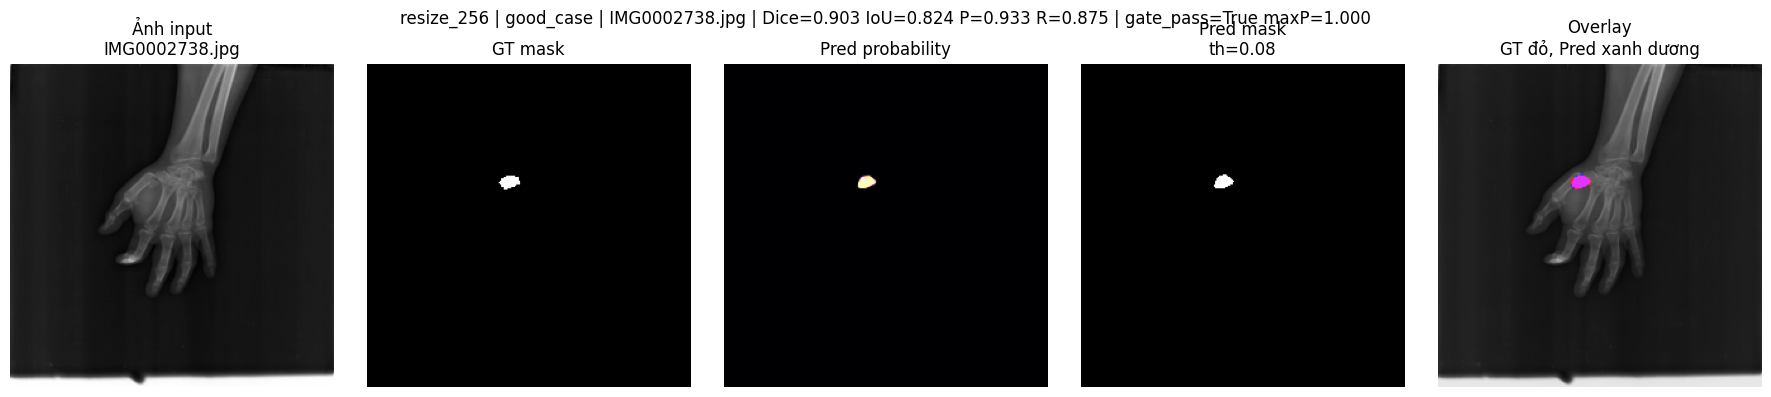

Saved: /content/fracatlas_unetpp_outputs/figures_overlay/overlay_resize_256_good_case_IMG0002738.jpg.png
--------------------------------------------------------------------------------
case_type: medium_case
image_id: IMG0003510.jpg
label: label_binary=fracture | label_3class=fracture
GT mask area original: 201
Metric ở threshold 0.08 : {'dice': 0.44134078227895507, 'iou': 0.28315412212073326, 'precision': 0.2851985562147297, 'recall': 0.9753086420057918, 'gt_mask_area': 81.0, 'pred_mask_area': 277.0}
Pred prob min/max/mean: 1.76393885609194e-10 1.0 0.0040377299301326275
threshold: 0.5 | pred_mask_area: 263
threshold: 0.4 | pred_mask_area: 265
threshold: 0.3 | pred_mask_area: 268
threshold: 0.2 | pred_mask_area: 273
threshold: 0.1 | pred_mask_area: 276
gate: pass= True | max_prob= 1.0 | soft_area_ratio= 0.00408935546875


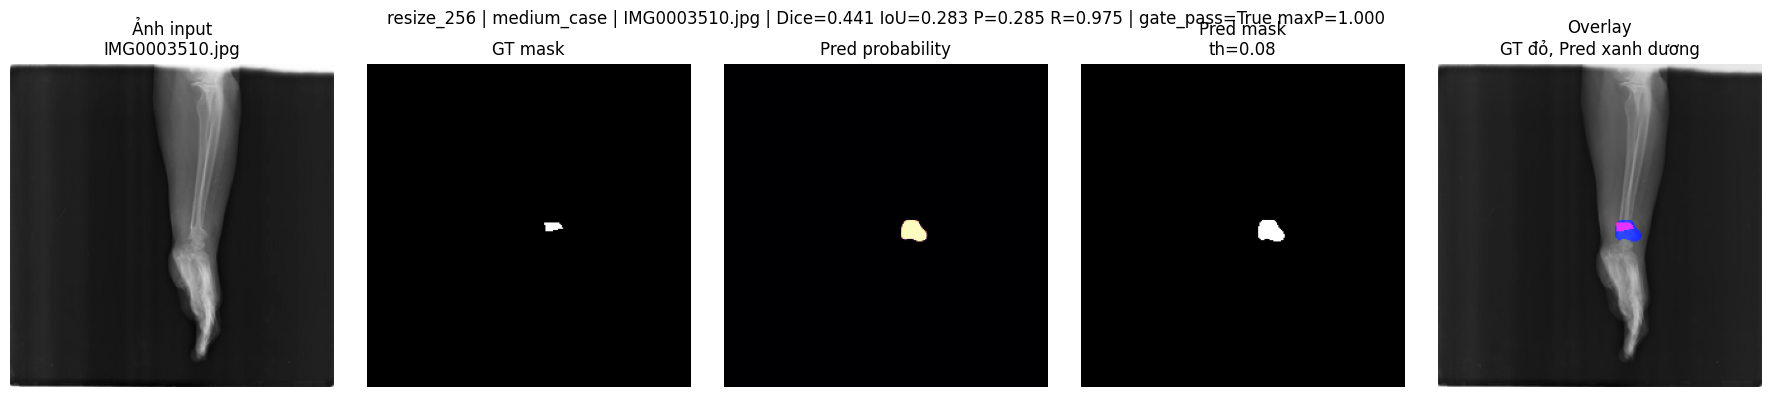

Saved: /content/fracatlas_unetpp_outputs/figures_overlay/overlay_resize_256_medium_case_IMG0003510.jpg.png
--------------------------------------------------------------------------------
case_type: fracture_false_negative
image_id: IMG0002840.jpg
label: label_binary=fracture | label_3class=fracture
GT mask area original: 141
Metric ở threshold 0.08 : {'dice': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0, 'gt_mask_area': 53.0, 'pred_mask_area': 0.0}
Pred prob min/max/mean: 1.417852280027887e-09 0.38825249671936035 6.586565723409876e-05
threshold: 0.5 | pred_mask_area: 0
threshold: 0.4 | pred_mask_area: 0
threshold: 0.3 | pred_mask_area: 4
threshold: 0.2 | pred_mask_area: 7
threshold: 0.1 | pred_mask_area: 14
gate: pass= False | max_prob= 0.38825249671936035 | soft_area_ratio= 6.103515625e-05


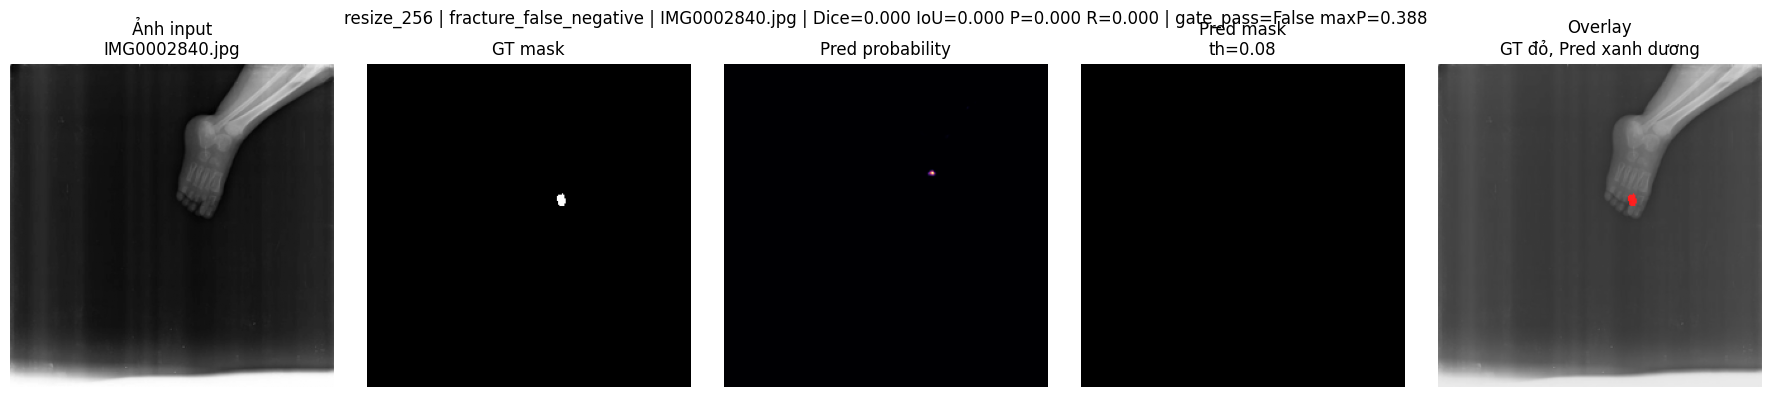

Saved: /content/fracatlas_unetpp_outputs/figures_overlay/overlay_resize_256_fracture_false_negative_IMG0002840.jpg.png
--------------------------------------------------------------------------------
case_type: normal_true_negative
image_id: IMG0003222.jpg
label: label_binary=normal | label_3class=normal
GT mask area original: 0
Metric ở threshold 0.08 : {'dice': 1.0, 'iou': 1.0, 'precision': 1.0, 'recall': 1.0, 'gt_mask_area': 0.0, 'pred_mask_area': 0.0}
Pred prob min/max/mean: 1.3140588173143897e-08 0.0009287312277592719 5.410260200733319e-06
threshold: 0.5 | pred_mask_area: 0
threshold: 0.4 | pred_mask_area: 0
threshold: 0.3 | pred_mask_area: 0
threshold: 0.2 | pred_mask_area: 0
threshold: 0.1 | pred_mask_area: 0
gate: pass= False | max_prob= 0.0009287312277592719 | soft_area_ratio= 0.0


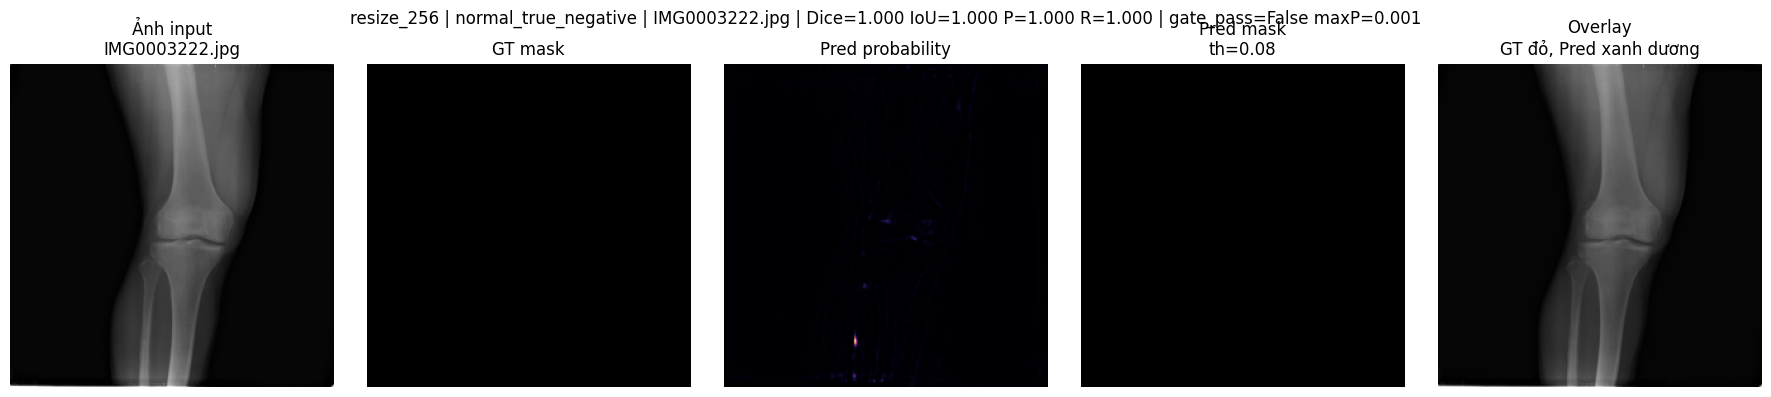

Saved: /content/fracatlas_unetpp_outputs/figures_overlay/overlay_resize_256_normal_true_negative_IMG0003222.jpg.png
--------------------------------------------------------------------------------
case_type: normal_false_positive
image_id: IMG0002219.jpg
label: label_binary=normal | label_3class=normal
GT mask area original: 0
Metric ở threshold 0.08 : {'dice': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0, 'gt_mask_area': 0.0, 'pred_mask_area': 603.0}
Pred prob min/max/mean: 8.497459957901299e-10 1.0 0.008540735580027103
threshold: 0.5 | pred_mask_area: 555
threshold: 0.4 | pred_mask_area: 568
threshold: 0.3 | pred_mask_area: 572
threshold: 0.2 | pred_mask_area: 584
threshold: 0.1 | pred_mask_area: 599
gate: pass= True | max_prob= 1.0 | soft_area_ratio= 0.00872802734375


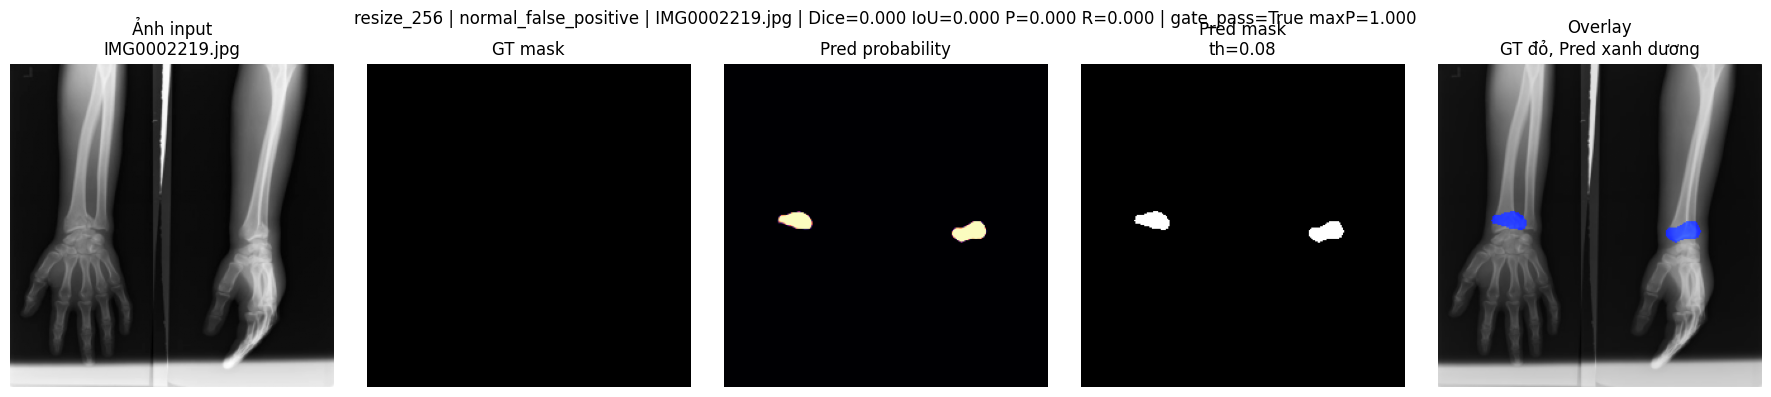

Saved: /content/fracatlas_unetpp_outputs/figures_overlay/overlay_resize_256_normal_false_positive_IMG0002219.jpg.png
--------------------------------------------------------------------------------
case_type: normal_false_positive
image_id: IMG0003117.jpg
label: label_binary=normal | label_3class=normal
GT mask area original: 0
Metric ở threshold 0.08 : {'dice': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0, 'gt_mask_area': 0.0, 'pred_mask_area': 567.0}
Pred prob min/max/mean: 2.6793391949553325e-09 1.0 0.007809809409081936
threshold: 0.5 | pred_mask_area: 518
threshold: 0.4 | pred_mask_area: 526
threshold: 0.3 | pred_mask_area: 534
threshold: 0.2 | pred_mask_area: 544
threshold: 0.1 | pred_mask_area: 564
gate: pass= True | max_prob= 1.0 | soft_area_ratio= 0.008148193359375


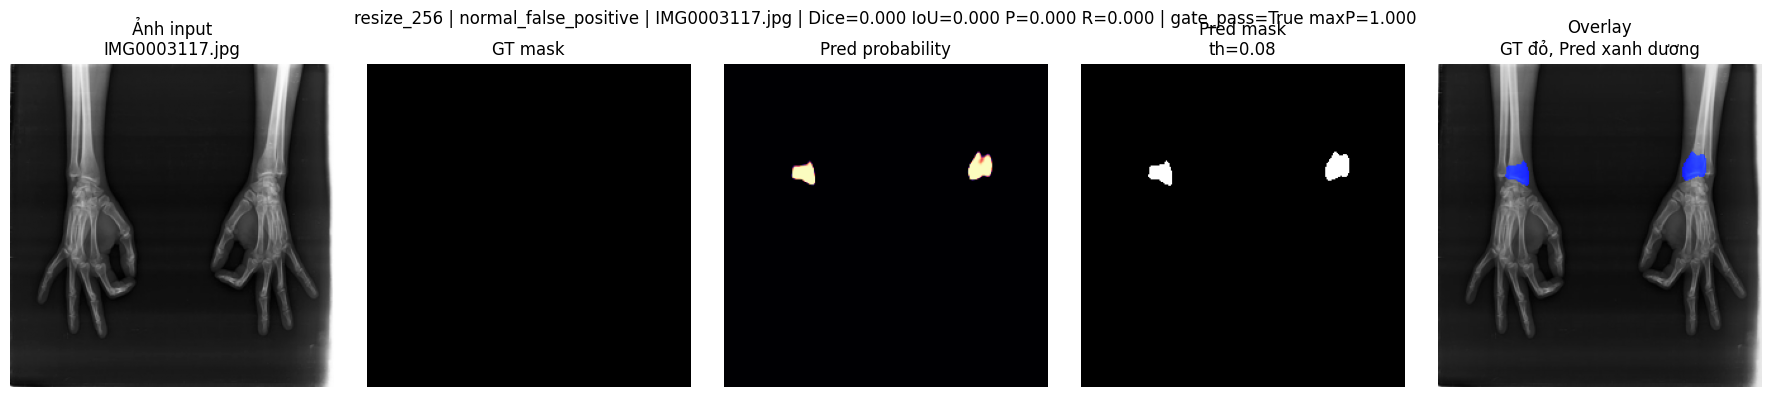

Saved: /content/fracatlas_unetpp_outputs/figures_overlay/overlay_resize_256_normal_false_positive_IMG0003117.jpg.png
VISUALIZATION MODE: no_resize_original
Selected demo cases:


,image_id,gt_mask_area_original,gt_mask_area,pred_mask_area,dice,iou,precision,recall,case_type
0,IMG0000454.jpg,1527.0,915.0,0.0,0.0,0.0,0.0,0.0,fracture_false_negative
1,IMG0001933.jpg,502.0,299.0,0.0,0.0,0.0,0.0,0.0,fracture_false_negative
2,IMG0000366.jpg,0.0,0.0,0.0,1.0,1.0,1.0,1.0,normal_true_negative
3,IMG0002559.jpg,1200.0,721.0,0.0,0.0,0.0,0.0,0.0,fracture_false_negative
4,IMG0000188.jpg,6309.0,92.0,0.0,0.0,0.0,0.0,0.0,fracture_false_negative
5,IMG0004150.jpg,330.0,195.0,0.0,0.0,0.0,0.0,0.0,fracture_false_negative


--------------------------------------------------------------------------------
case_type: fracture_false_negative
image_id: IMG0000454.jpg
label: label_binary=normal | label_3class=normal
GT mask area original: 1527
Metric ở threshold 0.03 : {'dice': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0, 'gt_mask_area': 915.0, 'pred_mask_area': 0.0}
Pred prob min/max/mean: 0.2883964776992798 0.9190903902053833 0.3528331518173218
threshold: 0.5 | pred_mask_area: 4570
threshold: 0.4 | pred_mask_area: 9725
threshold: 0.3 | pred_mask_area: 101492
threshold: 0.2 | pred_mask_area: 101728
threshold: 0.1 | pred_mask_area: 101728


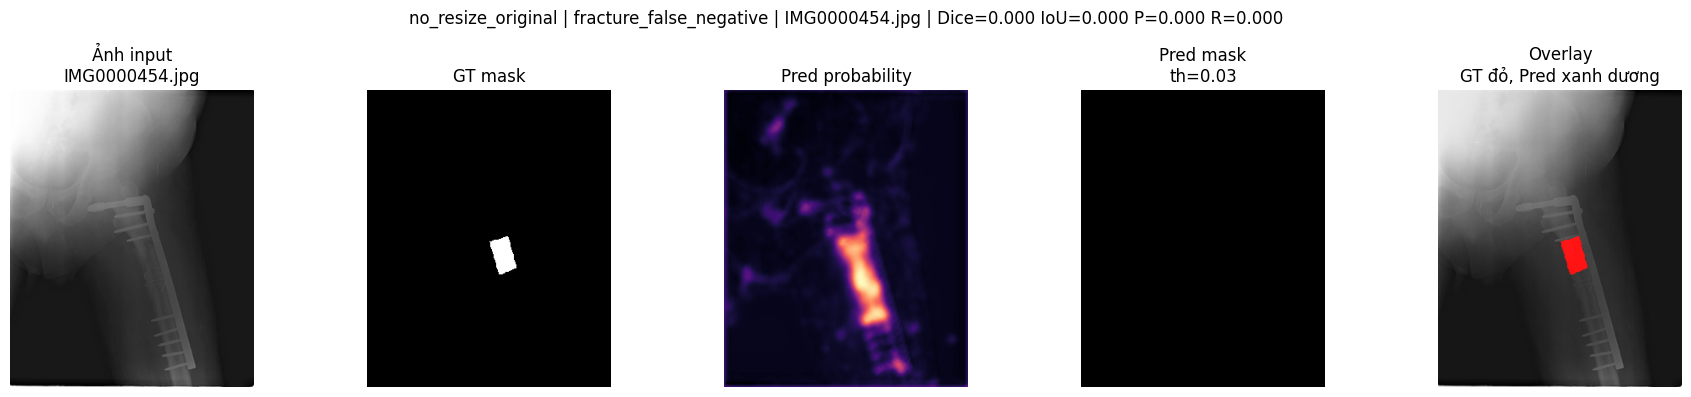

Saved: /content/fracatlas_unetpp_outputs/figures_overlay/overlay_no_resize_original_fracture_false_negative_IMG0000454.jpg.png
--------------------------------------------------------------------------------
case_type: fracture_false_negative
image_id: IMG0001933.jpg
label: label_binary=normal | label_3class=normal
GT mask area original: 502
Metric ở threshold 0.03 : {'dice': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0, 'gt_mask_area': 299.0, 'pred_mask_area': 0.0}
Pred prob min/max/mean: 0.2731279134750366 0.9713032245635986 0.3510704040527344
threshold: 0.5 | pred_mask_area: 4313
threshold: 0.4 | pred_mask_area: 8637
threshold: 0.3 | pred_mask_area: 100987
threshold: 0.2 | pred_mask_area: 101728
threshold: 0.1 | pred_mask_area: 101728


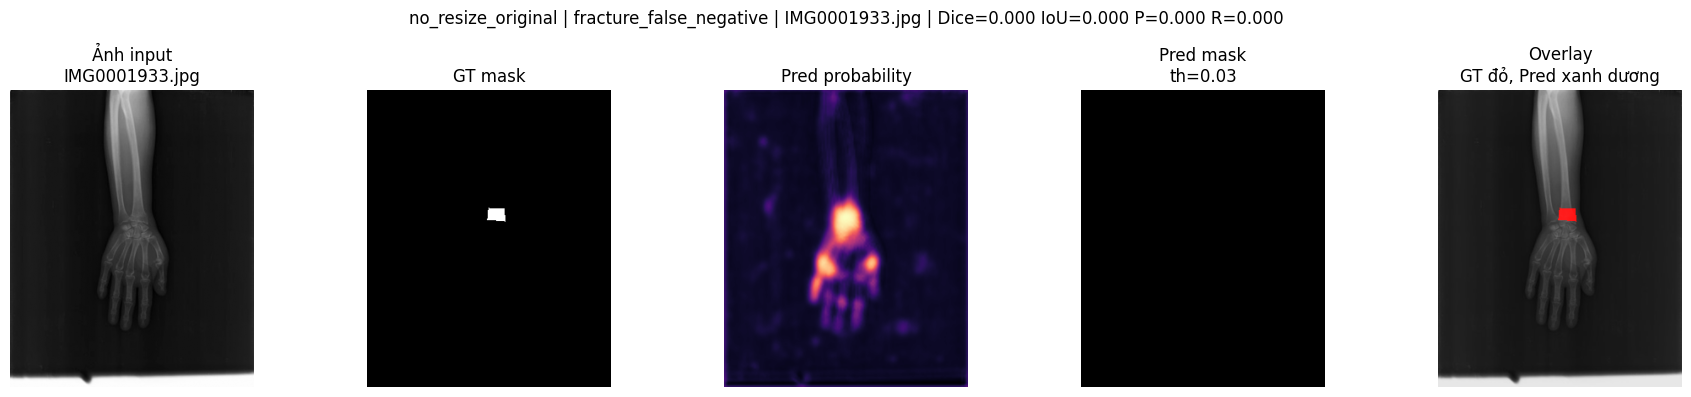

Saved: /content/fracatlas_unetpp_outputs/figures_overlay/overlay_no_resize_original_fracture_false_negative_IMG0001933.jpg.png
--------------------------------------------------------------------------------
case_type: normal_true_negative
image_id: IMG0000366.jpg
label: label_binary=normal | label_3class=normal
GT mask area original: 0
Metric ở threshold 0.03 : {'dice': 1.0, 'iou': 1.0, 'precision': 1.0, 'recall': 1.0, 'gt_mask_area': 0.0, 'pred_mask_area': 0.0}
Pred prob min/max/mean: 0.2645440697669983 0.9302010536193848 0.35432180762290955
threshold: 0.5 | pred_mask_area: 4454
threshold: 0.4 | pred_mask_area: 11699
threshold: 0.3 | pred_mask_area: 85982
threshold: 0.2 | pred_mask_area: 101728
threshold: 0.1 | pred_mask_area: 101728


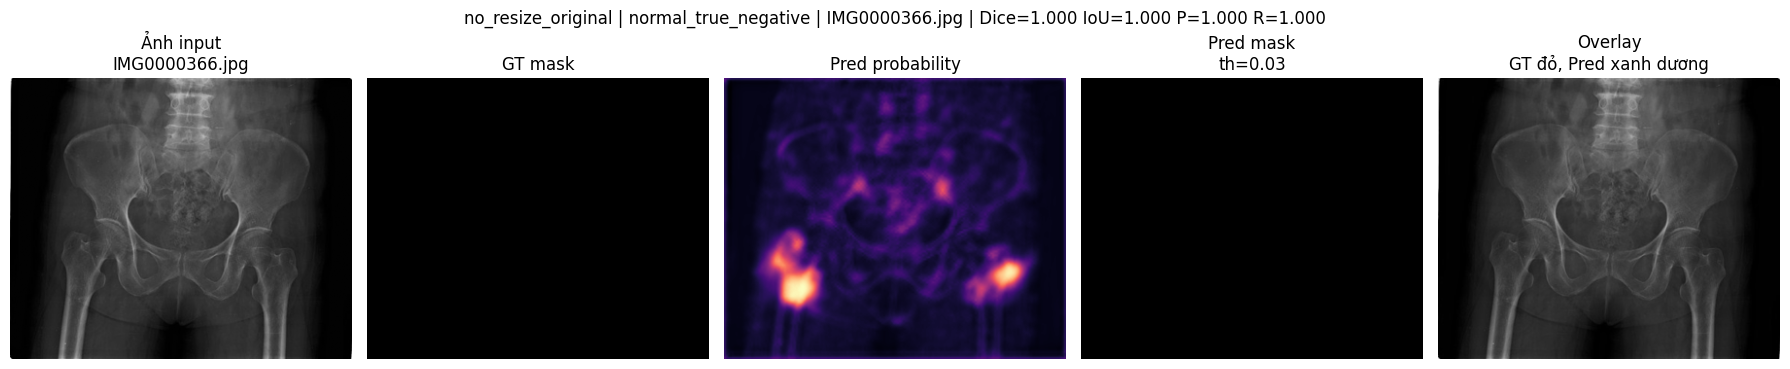

Saved: /content/fracatlas_unetpp_outputs/figures_overlay/overlay_no_resize_original_normal_true_negative_IMG0000366.jpg.png
--------------------------------------------------------------------------------
case_type: fracture_false_negative
image_id: IMG0002559.jpg
label: label_binary=normal | label_3class=normal
GT mask area original: 1200
Metric ở threshold 0.03 : {'dice': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0, 'gt_mask_area': 721.0, 'pred_mask_area': 0.0}
Pred prob min/max/mean: 0.2733961343765259 0.9520120024681091 0.35539358854293823
threshold: 0.5 | pred_mask_area: 4855
threshold: 0.4 | pred_mask_area: 11144
threshold: 0.3 | pred_mask_area: 96740
threshold: 0.2 | pred_mask_area: 101728
threshold: 0.1 | pred_mask_area: 101728


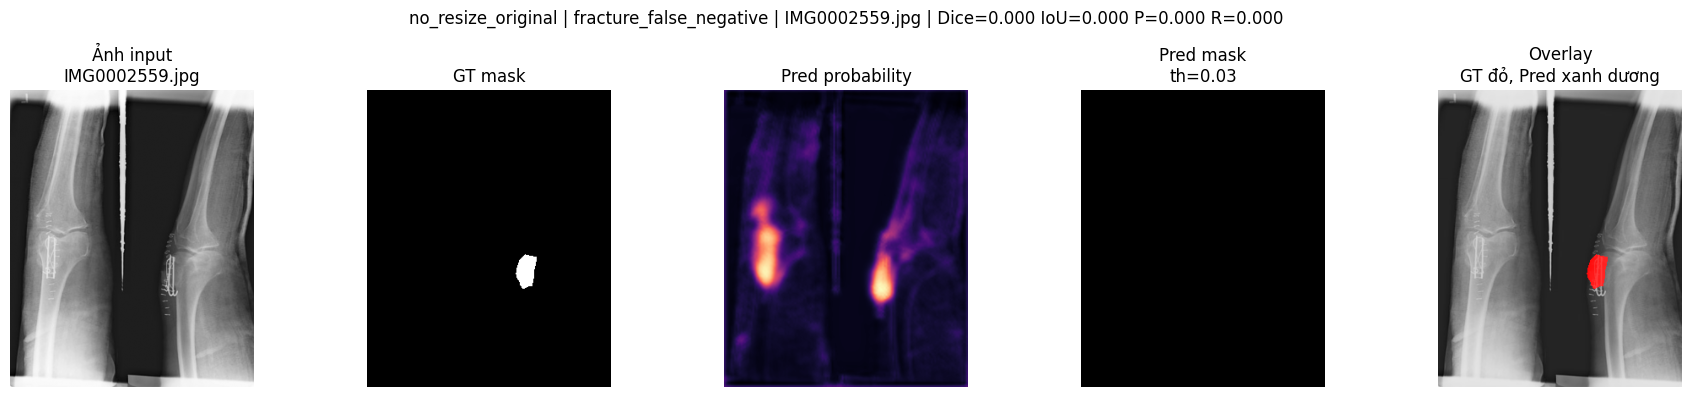

Saved: /content/fracatlas_unetpp_outputs/figures_overlay/overlay_no_resize_original_fracture_false_negative_IMG0002559.jpg.png
--------------------------------------------------------------------------------
case_type: fracture_false_negative
image_id: IMG0000188.jpg
label: label_binary=fracture | label_3class=fracture
GT mask area original: 6309
Metric ở threshold 0.03 : {'dice': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0, 'gt_mask_area': 92.0, 'pred_mask_area': 0.0}
Pred prob min/max/mean: 0.2905598282814026 0.9643848538398743 0.35338062047958374
threshold: 0.5 | pred_mask_area: 3410
threshold: 0.4 | pred_mask_area: 10778
threshold: 0.3 | pred_mask_area: 99135
threshold: 0.2 | pred_mask_area: 99264
threshold: 0.1 | pred_mask_area: 99264


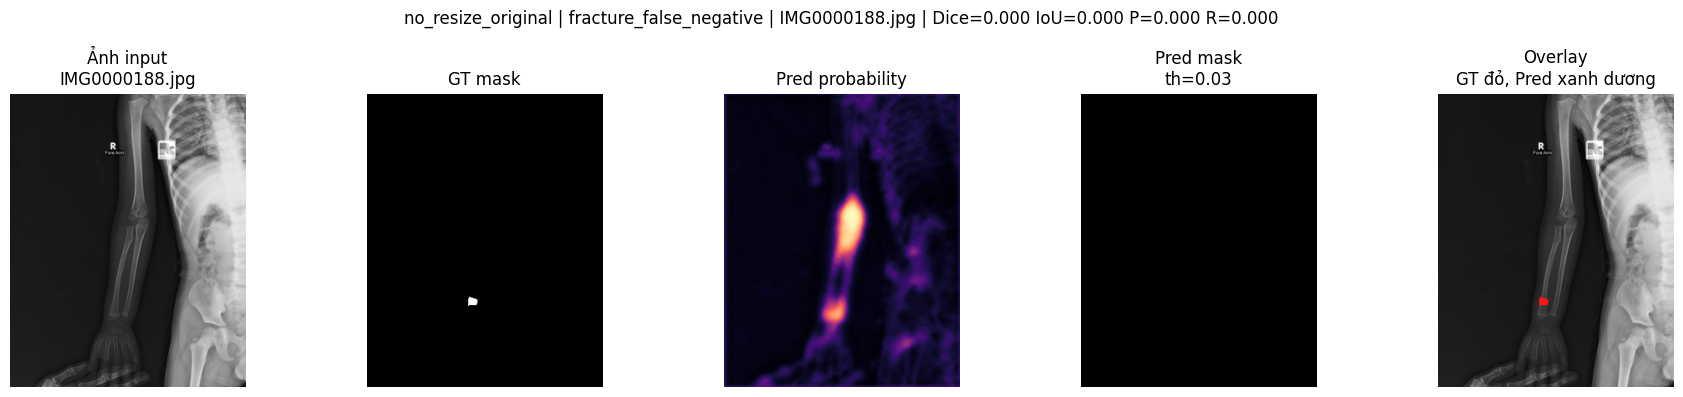

Saved: /content/fracatlas_unetpp_outputs/figures_overlay/overlay_no_resize_original_fracture_false_negative_IMG0000188.jpg.png
--------------------------------------------------------------------------------
case_type: fracture_false_negative
image_id: IMG0004150.jpg
label: label_binary=normal | label_3class=normal
GT mask area original: 330
Metric ở threshold 0.03 : {'dice': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0, 'gt_mask_area': 195.0, 'pred_mask_area': 0.0}
Pred prob min/max/mean: 0.3006584644317627 0.9576075077056885 0.35198089480400085
threshold: 0.5 | pred_mask_area: 4799
threshold: 0.4 | pred_mask_area: 7797
threshold: 0.3 | pred_mask_area: 101728
threshold: 0.2 | pred_mask_area: 101728
threshold: 0.1 | pred_mask_area: 101728


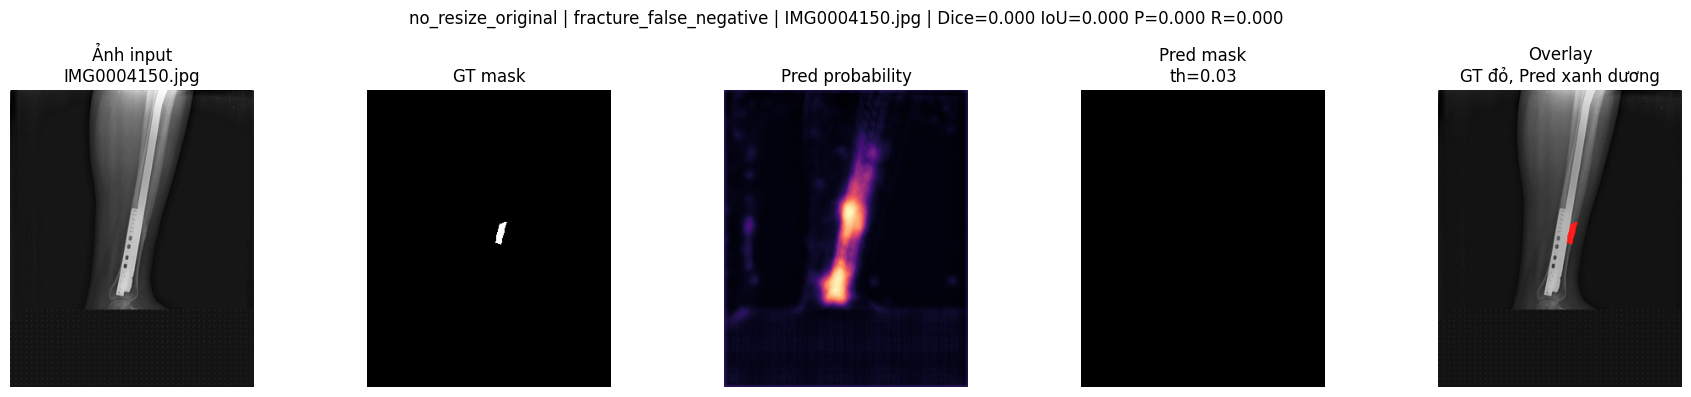

Saved: /content/fracatlas_unetpp_outputs/figures_overlay/overlay_no_resize_original_fracture_false_negative_IMG0004150.jpg.png


In [ ]:
# ============================================================
# 11. VISUALIZATION
# ============================================================

FIG_DIR = OUTPUT_DIR / "figures_overlay"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def predict_one(model, dataset, idx, threshold, preprocess_mode, gate_config=None):
    model.eval()
    x, y, meta = dataset[idx]
    with torch.no_grad():
        xx = x.unsqueeze(0).to(DEVICE)
        yy = y.unsqueeze(0).to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
            logits = model(xx)
            logits = resize_logits_to_target(logits, yy)
            prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

    gt = y[0].numpy().astype(np.uint8)
    pred, gate_info = make_prediction_from_prob(
        prob,
        preprocess_mode=preprocess_mode,
        seg_threshold=threshold,
        gate_config=gate_config,
    )
    metrics = compute_segmentation_metrics(pred, gt)
    metrics.update(gate_info)
    return x, gt, prob, pred, meta, metrics


def denormalize_for_display(x_tensor):
    arr = x_tensor.detach().cpu().numpy()
    arr = np.transpose(arr, (1, 2, 0))
    arr = arr * IMAGENET_STD + IMAGENET_MEAN
    arr = np.clip(arr, 0, 1)
    # Ảnh grayscale lặp 3 channel, lấy channel đầu để hiển thị.
    return arr[:, :, 0]


def make_overlay_base_style(img_gray, gt, pred):
    """Overlay: GT đỏ, Pred xanh dương."""
    rgb = np.stack([img_gray, img_gray, img_gray], axis=-1)
    overlay = rgb.copy()
    gt_bool = gt.astype(bool)
    pred_bool = pred.astype(bool)

    # GT đỏ.
    overlay[gt_bool, 0] = 1.0
    overlay[gt_bool, 1] *= 0.35
    overlay[gt_bool, 2] *= 0.35

    # Pred xanh dương.
    overlay[pred_bool, 0] *= 0.35
    overlay[pred_bool, 1] *= 0.55
    overlay[pred_bool, 2] = 1.0

    # Vùng trùng màu tím.
    both = gt_bool & pred_bool
    overlay[both, 0] = 0.9
    overlay[both, 1] = 0.2
    overlay[both, 2] = 1.0
    return np.clip(overlay, 0, 1)


def _append_unique_rows(parts, used, df, max_rows):
    if df is None or len(df) == 0 or max_rows <= 0:
        return
    chosen = []
    for _, row in df.iterrows():
        key = int(row["row_index"])
        if key not in used:
            used.add(key)
            chosen.append(row)
        if len(chosen) >= max_rows:
            break
    if chosen:
        parts.append(pd.DataFrame(chosen))


def select_demo_rows(result_df, n=8):
    """Chọn case minh họa gồm ảnh có mask tốt/trung bình/khó và ảnh normal đúng/sai."""
    parts = []
    used = set()

    pos_df = result_df[result_df["gt_mask_area"] > 0].copy()
    normal_df = result_df[result_df["gt_mask_area"] == 0].copy()

    if len(pos_df) > 0:
        _append_unique_rows(parts, used, pos_df.sort_values("dice", ascending=False), 1)

        mid_df = pos_df[(pos_df["dice"] >= 0.20) & (pos_df["dice"] <= 0.70)].copy()
        if len(mid_df) > 0:
            mid_df["mid_dist"] = (mid_df["dice"] - 0.45).abs()
            mid_df = mid_df.sort_values("mid_dist").drop(columns=["mid_dist"])
            _append_unique_rows(parts, used, mid_df, 1)

        _append_unique_rows(parts, used, pos_df.sort_values("dice", ascending=True), 1)

    normal_tn = normal_df[normal_df["pred_mask_area"] == 0].copy()
    normal_fp = normal_df[normal_df["pred_mask_area"] > 0].copy()

    _append_unique_rows(parts, used, normal_tn.sort_values("dice", ascending=False), 1)
    _append_unique_rows(parts, used, normal_fp.sort_values("pred_mask_area", ascending=False), 2)

    remaining = result_df[~result_df["row_index"].isin(list(used))].copy()
    _append_unique_rows(parts, used, remaining.sort_values("dice", ascending=True), max(0, n - sum(len(p) for p in parts)))

    if len(parts) == 0:
        return result_df.head(n)

    out = pd.concat(parts, ignore_index=True).drop_duplicates(subset=["row_index"])
    return out.head(n)


def describe_demo_case(row):
    gt_area = float(row["gt_mask_area"])
    pred_area = float(row["pred_mask_area"])
    dice = row["dice"]
    if "case_type" in row.index and pd.notna(row["case_type"]):
        return str(row["case_type"])
    if gt_area == 0 and pred_area == 0:
        return "normal_true_negative"
    if gt_area == 0 and pred_area > 0:
        return "normal_false_positive"
    if gt_area > 0 and pred_area == 0:
        return "fracture_false_negative"
    if not pd.isna(dice) and float(dice) >= 0.70:
        return "good_case"
    if not pd.isna(dice) and float(dice) < 0.20:
        return "hard_or_error_case"
    return "medium_case"


def get_case_label(meta, gt):
    """Lấy label nếu CSV có sẵn; nếu không có thì suy từ GT mask."""
    label_parts = []
    try:
        row_idx = int(meta.get("row_index", -1))
        if 0 <= row_idx < len(test_df):
            raw_row = test_df.iloc[row_idx]
            for col in ["label", "label_binary", "label_3class", "class", "diagnosis", "target", "fracture", "fractured"]:
                if col in raw_row.index and pd.notna(raw_row[col]):
                    label_parts.append(f"{col}={raw_row[col]}")
    except Exception:
        pass

    if label_parts:
        return " | ".join(label_parts)
    return "fracture" if int(gt.sum()) > 0 else "normal"


def core_metric_dict(metrics):
    keys = ["dice", "iou", "precision", "recall", "gt_mask_area", "pred_mask_area"]
    out = {}
    for k in keys:
        v = metrics.get(k, np.nan)
        out[k] = None if pd.isna(v) else float(v)
    return out


def print_base_style_case_info(meta, gt, prob, pred, metrics, threshold):
    print("image_id:", meta.get("image_id", ""))
    print("label:", get_case_label(meta, gt))
    print("GT mask area original:", int(float(meta.get("gt_mask_area_original", float(gt.sum())))))
    print(f"Metric ở threshold {threshold} :", core_metric_dict(metrics))
    print("Pred prob min/max/mean:", float(prob.min()), float(prob.max()), float(prob.mean()))
    for th in [0.5, 0.4, 0.3, 0.2, 0.1]:
        area = int((prob > th).sum())
        print("threshold:", th, "| pred_mask_area:", area)
    if bool(metrics.get("gate_enabled", False)):
        print(
            "gate:",
            "pass=", bool(metrics.get("gate_pass", True)),
            "| max_prob=", float(metrics.get("gate_max_prob", np.nan)),
            "| soft_area_ratio=", float(metrics.get("gate_soft_area_ratio", np.nan)),
        )


for mode in RUN_MODES:
    if mode not in TRAINED_MODELS:
        print("Skip visualization, model not in memory:", mode)
        continue
    print("=" * 80)
    print("VISUALIZATION MODE:", mode)
    print("=" * 80)
    model = TRAINED_MODELS[mode].to(DEVICE)
    result_df = result_dfs[mode]
    summary_row = summary_df.loc[summary_df["raw_preprocess_mode"] == mode].iloc[0]
    thr = float(summary_row.get("seg_threshold", summary_row["threshold"]))
    gate_config = gate_config_from_summary_row(summary_row)
    demo_rows = select_demo_rows(result_df, DEMO_N_PER_MODE)
    viz_test_df = TEST_DF_BY_MODE.get(mode, test_df).reset_index(drop=True)
    ds = FracAtlasSegmentationDataset(viz_test_df, DATA_ROOT, preprocess_mode=mode, train=False)

    print("Selected demo cases:")
    show_cols = ["image_id", "gt_mask_area_original", "gt_mask_area", "pred_mask_area", "dice", "iou", "precision", "recall", "case_type"]
    show_cols = [c for c in show_cols if c in demo_rows.columns]
    display(demo_rows[show_cols])

    for _, r in demo_rows.iterrows():
        idx = int(r["row_index"])
        x, gt, prob, pred, meta, metrics = predict_one(model, ds, idx, thr, mode, gate_config=gate_config)
        img_gray = denormalize_for_display(x)
        overlay = make_overlay_base_style(img_gray, gt, pred)
        case_kind = describe_demo_case(r)

        print("-" * 80)
        print("case_type:", case_kind)
        print_base_style_case_info(meta, gt, prob, pred, metrics, thr)

        fig, axes = plt.subplots(1, 5, figsize=(18, 4))
        axes[0].imshow(img_gray, cmap="gray")
        axes[0].set_title(f"Ảnh input\n{meta['image_id']}")
        axes[1].imshow(gt, cmap="gray")
        axes[1].set_title("GT mask")
        axes[2].imshow(prob, cmap="magma")
        axes[2].set_title("Pred probability")
        axes[3].imshow(pred, cmap="gray")
        axes[3].set_title(f"Pred mask\nth={thr}")
        axes[4].imshow(overlay)
        axes[4].set_title("Overlay\nGT đỏ, Pred xanh dương")
        for ax in axes:
            ax.axis("off")

        recall_text = "nan" if pd.isna(metrics["recall"]) else f"{metrics['recall']:.3f}"
        gate_text = ""
        if bool(metrics.get("gate_enabled", False)):
            gate_text = f" | gate_pass={bool(metrics.get('gate_pass', True))} maxP={float(metrics.get('gate_max_prob', np.nan)):.3f}"
        title = f"{mode} | {case_kind} | {meta['image_id']} | Dice={metrics['dice']:.3f} IoU={metrics['iou']:.3f} P={metrics['precision']:.3f} R={recall_text}{gate_text}"
        fig.suptitle(title)
        plt.tight_layout()

        safe_image_id = str(meta['image_id']).replace('/', '_').replace('\\', '_')
        safe_case_kind = case_kind.replace(' ', '_').replace('/', '_')
        out_path = FIG_DIR / f"overlay_{mode}_{safe_case_kind}_{safe_image_id}.png"
        plt.savefig(out_path, dpi=140, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path)

In [ ]:
# ============================================================
# 12. ĐỌC KẾT QUẢ THEO STYLE BASE NOTEBOOK — KHÔNG RERUN EXPERIMENT
# ============================================================

required_objects = ["summary_df", "result_dfs"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Bạn cần chạy Cell 9 trước khi chạy cell này. Thiếu object: " + ", ".join(missing_objects)
    )

pd.set_option("display.max_columns", None)

readable_summary_rows = []
for _, r in summary_df.iterrows():
    readable_summary_rows.append({
        "mode": r.get("preprocess_mode", ""),
        "raw_mode": r.get("raw_preprocess_mode", ""),
        "n_test": int(r.get("n_test", 0)),
        "n_ảnh_có_mask_thật": int(r.get("n_positive_gt", 0)),
        "n_ảnh_normal": int(r.get("n_normal_gt", 0)),
        "seg_threshold": r.get("seg_threshold", r.get("threshold", np.nan)),
        "gate_enabled": r.get("gate_enabled", False),
        "dice_toàn_test": r.get("dice_all", np.nan),
        "iou_toàn_test": r.get("iou_all", np.nan),
        "dice_trên_ảnh_có_mask_thật": r.get("dice_positive", np.nan),
        "iou_trên_ảnh_có_mask_thật": r.get("iou_positive", np.nan),
        "normal_false_positive_rate": r.get("normal_false_positive_rate", np.nan),
        "normal_empty_pred_rate": r.get("normal_empty_pred_rate", np.nan),
        "epochs_ran": r.get("epochs_ran", np.nan),
    })
print("Bảng đọc nhanh summary:")
display(pd.DataFrame(readable_summary_rows))

print("\nCác mode đã có result_df:", list(result_dfs.keys()))

for mode, df in result_dfs.items():
    print("=" * 80)
    print("MODE:", mode)
    print("rows:", len(df), "| ảnh có mask thật:", int((df["gt_mask_area"] > 0).sum()), "| ảnh normal:", int((df["gt_mask_area"] == 0).sum()))

    metric_cols = ["dice", "iou", "precision", "recall"]

    print("\nMetric trung bình toàn test subset:")
    display(df[metric_cols].mean())

    if "case_type" not in df.columns:
        df = df.copy()
        df["case_type"] = df.apply(lambda r: classify_eval_case_from_metrics(r["gt_mask_area"], r["pred_mask_area"], r["dice"]), axis=1)

    print("\nSố case theo loại:")
    print(df["case_type"].value_counts())

    mask_eval = df[df["gt_mask_area"] > 0]
    if len(mask_eval) > 0:
        print("\nMetric trên ảnh có mask thật:")
        display(mask_eval[metric_cols].mean())

    normal_eval = df[df["gt_mask_area"] == 0]
    if len(normal_eval) > 0:
        normal_false_positive_rate = float((normal_eval["pred_mask_area"] > 0).mean())
        normal_empty_pred_rate = float((normal_eval["pred_mask_area"] == 0).mean())
        print("\nẢnh normal:")
        print("normal_empty_pred_rate:", normal_empty_pred_rate)
        print("normal_false_positive_rate:", normal_false_positive_rate)

Bảng đọc nhanh summary:


,mode,raw_mode,n_test,n_ảnh_có_mask_thật,n_ảnh_normal,seg_threshold,gate_enabled,dice_toàn_test,iou_toàn_test,dice_trên_ảnh_có_mask_thật,iou_trên_ảnh_có_mask_thật,normal_false_positive_rate,normal_empty_pred_rate,epochs_ran
0,resize,resize_256,613,108,505,0.08,True,0.347816,0.327381,0.511216,0.395226,0.687129,0.312871,40
1,no_resize,no_resize_original,160,23,137,0.03,False,0.856250,0.856250,0.000000,0.000000,0.000000,1.000000,4



Các mode đã có result_df: ['resize_256', 'no_resize_original']
MODE: resize_256
rows: 613 | ảnh có mask thật: 108 | ảnh normal: 505

Metric trung bình toàn test subset:


,0
dice,0.347816
iou,0.327381
precision,0.346177
recall,0.360089



Số case theo loại:
case_type
normal_false_positive      347
normal_true_negative       158
medium_case                 45
good_case                   40
hard_or_error_case          18
fracture_false_negative      5
Name: count, dtype: int64

Metric trên ảnh có mask thật:


...


Ảnh normal:
normal_empty_pred_rate: 0.31287128712871287
normal_false_positive_rate: 0.6871287128712872
MODE: no_resize_original
rows: 160 | ảnh có mask thật: 23 | ảnh normal: 137

Metric trung bình toàn test subset:


,0
dice,0.85625
iou,0.85625
precision,0.85625
recall,0.85625



Số case theo loại:
case_type
normal_true_negative       137
fracture_false_negative     23
Name: count, dtype: int64

Metric trên ảnh có mask thật:


,0
dice,0.0
iou,0.0
precision,0.0
recall,0.0



Ảnh normal:
normal_empty_pred_rate: 1.0
normal_false_positive_rate: 0.0


In [ ]:
# ============================================================
# 12. BACKUP TO GOOGLE DRIVE - CHẠY CELL NÀY SAU KHI TRAIN/EVALUATE
# ============================================================

from pathlib import Path
from datetime import datetime
import shutil
import zipfile
import os

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Không mount được Google Drive, vẫn thử backup nếu thư mục Drive đã có sẵn.")
    print("Chi tiết:", e)

src_dir = Path(OUTPUT_DIR) if "OUTPUT_DIR" in globals() else Path("/content/fracatlas_unetpp_outputs")
if not src_dir.exists():
    raise FileNotFoundError(f"Không thấy OUTPUT_DIR: {src_dir}")

backup_root = Path("/content/drive/MyDrive/acv_segmentation_outputs")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

latest_dir = backup_root / "latest"
snapshot_dir = backup_root / "snapshots" / f"{src_dir.name}_{timestamp}"
zip_dir = backup_root / "zips"
zip_path = zip_dir / f"{src_dir.name}_{timestamp}.zip"

for d in [backup_root, snapshot_dir.parent, zip_dir]:
    d.mkdir(parents=True, exist_ok=True)

if latest_dir.exists():
    shutil.rmtree(latest_dir)
shutil.copytree(src_dir, latest_dir)

shutil.copytree(src_dir, snapshot_dir)

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in snapshot_dir.rglob("*"):
        if p.is_file():
            zf.write(p, arcname=p.relative_to(snapshot_dir))

files = [p for p in src_dir.rglob("*") if p.is_file()]
size_mb = sum(p.stat().st_size for p in files) / (1024 ** 2)

print("Backup xong.")
print("Nguồn:", src_dir)
print("Số file:", len(files))
print(f"Dung lượng: {size_mb:.2f} MB")
print("Latest:", latest_dir)
print("Snapshot:", snapshot_dir)
print("Zip:", zip_path)

print("\nMột số file chính trong latest:")
for name in [
    f"results_{GROUP_NAME}.csv" if "GROUP_NAME" in globals() else "results_Group07.csv",
    "metrics_summary_compare_preprocess_modes.csv",
    "all_test_predictions_with_image_id.csv",
    "Template_Result_Segmentation_filled.csv",
]:
    p = latest_dir / name
    print(("OK " if p.exists() else "-- "), p)

print("\nCó thể tải lại từ Drive hoặc dùng zip ở đường dẫn trên.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Backup xong.
Nguồn: /content/fracatlas_unetpp_outputs
Số file: 27
Dung lượng: 111.38 MB
Latest: /content/drive/MyDrive/acv_segmentation_outputs/latest
Snapshot: /content/drive/MyDrive/acv_segmentation_outputs/snapshots/fracatlas_unetpp_outputs_20260624_101511
Zip: /content/drive/MyDrive/acv_segmentation_outputs/zips/fracatlas_unetpp_outputs_20260624_101511.zip

Một số file chính trong latest:
OK  /content/drive/MyDrive/acv_segmentation_outputs/latest/results_Group07.csv
OK  /content/drive/MyDrive/acv_segmentation_outputs/latest/metrics_summary_compare_preprocess_modes.csv
OK  /content/drive/MyDrive/acv_segmentation_outputs/latest/all_test_predictions_with_image_id.csv
OK  /content/drive/MyDrive/acv_segmentation_outputs/latest/Template_Result_Segmentation_filled.csv

Có thể tải lại từ Drive hoặc dùng zip ở đường dẫn trên.
